### Import libraries

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
import colorsys
import heapq
import random
import copy

from mesa import Agent, Model
from mesa.time import BaseScheduler
from mesa.datacollection import DataCollector
from IPython.display import display

### Lecture .csv

Nous commençons par charger la base de données déjà nettoyée et préparée dans le notebook `analyse_amont.ipynb`.  
Cette base constitue le point de départ du travail et contient les informations historiques nécessaires pour construire la simulation.

In [2]:
df = pd.read_csv("../2.0_analyse_amont/df_analyse_amont.csv")
df.head()

C:\Users\agus\AppData\Local\Temp\ipykernel_5256\1417404454.py:1: DtypeWarning: Columns (11,12,14,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../2.0_analyse_amont/df_analyse_amont.csv")


,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,1,0,0,47.0,50.0,0.118129,-1.090800,1.308571,-1.855631,-0.624738
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,0,1,0,116.0,74.0,2.192266,0.107738,-1.414844,-1.254767,-1.074449
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,0,1,0,NaN,5.0,0.096306,-0.465269,-2.492932,-1.216424,1.195746
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,1,0,0,74.0,53.0,-1.001173,0.115672,0.395099,-0.513320,-0.695704
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,1,0,0,79.0,20.0,-0.000047,0.384547,0.760444,-1.609653,1.700027


In [3]:
df.columns

Index(['num_dordre', 'date', 'heure',
       '_informations_du_passage_date_et_heure_darrive',
       '_informations_du_passage_moyen_darrive', '_iao_motif_dentre',
       '_iao_motif_de_venue', '_patient_age_en_anne',
       '_antcdent_antcdents_mdicaux', '_antcdent_antcdents_chirurgicaux',
       '_constante_surveillances_paspad_adultes_premire_valeur',
       '_constante_surveillances_fc_adultes_premire_valeur',
       '_constante_surveillances_temprature_adultes_premire_valeur',
       '_constante_surveillances_sao2_adultes_premire_valeur',
       '_constante_surveillances_frquence_respiratoire_premire_valeur',
       '_diagnostic_code_ccmu', '_localisation_salles',
       '_localisation_date_dentre_en_box', '_anamnse_texte',
       '_iao_observation', '_examens_complmentaires_a_des_examens_de_biologie',
       '_examens_complmentaires_a_des_examens_de_radiologie',
       '_examens_complmentaires_a_des_examens_dchographie',
       '_examens_complmentaires_a_des_examens_de_scanner',

Nous ajoutons une colonne `service` indiquant le service vers lequel chaque patient est orienté.  
Cette information est extraite de la colonne `_iao_motif_de_venue` en conservant la partie située avant les deux points `:`.

In [4]:
df["service"] = (
    df["_iao_motif_de_venue"]
    .str.split(":", n=1)
    .str[0]
    .str.strip()
)

In [5]:
df["service"].value_counts()

service
Traumatologie                                  60669
Gastro-entérologie                             46968
Stomatologie                                   32855
Cardiologie                                    31939
Neurologie                                     25770
Orl                                            17220
Rhumatologie non traumatique                   16884
Divers                                         14929
Uro-néphrologie                                14277
Pneumologie                                    14136
Psychiatrie                                     8281
Dermatologie                                    6927
Neuro-chirurgie                                 3815
Maladies infectieuses                           3124
Toxicologie                                     2706
Endocrino-métabolisme                           1808
Hématologie                                     1554
Allergies                                       1434
Vasculaire                            

### Préparation df_sma

Nous préparons un dataframe appelé `df_sma` qui contient uniquement les variables nécessaires au modèle SMA.  
Ce dataframe sera utilisé tout au long de la notebook pour alimenter la simulation.

In [6]:
df_sma = df[["num_dordre", "datetime_arrivee", "service", "_diagnostic_code_ccmu", "_examens_complmentaires_a_des_examens_de_biologie", "_examens_complmentaires_a_des_examens_de_radiologie", "_examens_complmentaires_a_des_examens_dchographie", "_examens_complmentaires_a_des_examens_de_scanner", "_examens_complmentaires_a_des_examens_dirm", "_examens_complmentaires_a_des_avis_de_spcialistes", "is_retour_domicile", "is_transfert", "is_hospit", "delai_total_calc", "delai_arrivee_PEC_cap"]]
df_sma

,num_dordre,datetime_arrivee,service,_diagnostic_code_ccmu,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes,is_retour_domicile,is_transfert,is_hospit,delai_total_calc,delai_arrivee_PEC_cap
0,1,2016-06-01 00:16:00,Cardiologie,1,oui,oui,non,non,non,non,1,0,0,238.0,47.0
1,2,2016-06-01 00:18:00,Maladies infectieuses,2,oui,oui,non,non,non,non,0,1,0,647.0,116.0
2,3,2016-06-01 00:36:00,NaN,2,non,non,non,non,non,oui,0,1,0,148.0,NaN
3,4,2016-06-01 00:43:00,Maladies infectieuses,1,oui,non,non,non,non,non,1,0,0,247.0,74.0
4,5,2016-06-01 01:16:00,Cardiologie,2,oui,non,non,non,non,oui,1,0,0,879.0,79.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336248,336249,2020-06-01 22:58:00,Uro-néphrologie,2,oui,non,non,oui,non,oui,0,1,0,1312.0,171.0
336249,336250,2020-06-01 23:03:00,Endocrino-métabolisme,2,oui,non,non,non,non,non,1,0,0,264.0,NaN
336250,336251,2020-06-01 23:04:00,Uro-néphrologie,2,oui,non,non,non,non,non,1,0,0,244.0,241.0
336251,336252,2020-06-01 23:12:00,Gastro-entérologie,2,oui,non,non,non,non,non,1,0,0,261.0,251.0


In [7]:
df_sma = df_sma.dropna(subset=["service","_diagnostic_code_ccmu"]).copy()

In [8]:
df_sma = df_sma[~df_sma["_diagnostic_code_ccmu"].isin(["P", "D"])].copy()

In [9]:
df_sma._diagnostic_code_ccmu.value_counts()

_diagnostic_code_ccmu
2    220759
1     32510
3     17397
4      1911
5       482
Name: count, dtype: int64

In [10]:
cols_oui_non = [
    "_examens_complmentaires_a_des_examens_de_biologie",
    "_examens_complmentaires_a_des_examens_de_radiologie",
    "_examens_complmentaires_a_des_examens_dchographie",
    "_examens_complmentaires_a_des_examens_de_scanner",
    "_examens_complmentaires_a_des_examens_dirm",
    "_examens_complmentaires_a_des_avis_de_spcialistes",
]

In [11]:
for col in cols_oui_non:
    df_sma[col] = (
        df_sma[col]
        .str.strip()
        .str.lower()
        .map({"oui": 1, "non": 0})
    )

In [12]:
df_sma[cols_oui_non].head()

,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes
0,1,1,0,0,0,0
1,1,1,0,0,0,0
3,1,0,0,0,0,0
4,1,0,0,0,0,1
5,0,0,0,0,0,1


In [13]:
df_sma.service.value_counts()

service
Traumatologie                                  55918
Gastro-entérologie                             41126
Stomatologie                                   30336
Cardiologie                                    29374
Neurologie                                     23048
Orl                                            16202
Rhumatologie non traumatique                   15925
Uro-néphrologie                                13136
Divers                                         12412
Pneumologie                                    12281
Dermatologie                                    6462
Neuro-chirurgie                                 3325
Psychiatrie                                     3218
Maladies infectieuses                           2617
Toxicologie                                     1873
Endocrino-métabolisme                           1532
Allergies                                       1371
Hématologie                                     1110
Vasculaire                            

In [14]:
df_sma.columns

Index(['num_dordre', 'datetime_arrivee', 'service', '_diagnostic_code_ccmu',
       '_examens_complmentaires_a_des_examens_de_biologie',
       '_examens_complmentaires_a_des_examens_de_radiologie',
       '_examens_complmentaires_a_des_examens_dchographie',
       '_examens_complmentaires_a_des_examens_de_scanner',
       '_examens_complmentaires_a_des_examens_dirm',
       '_examens_complmentaires_a_des_avis_de_spcialistes',
       'is_retour_domicile', 'is_transfert', 'is_hospit', 'delai_total_calc',
       'delai_arrivee_PEC_cap'],
      dtype='object')

In [15]:
df_sma.head(50)

,num_dordre,datetime_arrivee,service,_diagnostic_code_ccmu,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes,is_retour_domicile,is_transfert,is_hospit,delai_total_calc,delai_arrivee_PEC_cap
0,1,2016-06-01 00:16:00,Cardiologie,1,1,1,0,0,0,0,1,0,0,238.0,47.0
1,2,2016-06-01 00:18:00,Maladies infectieuses,2,1,1,0,0,0,0,0,1,0,647.0,116.0
3,4,2016-06-01 00:43:00,Maladies infectieuses,1,1,0,0,0,0,0,1,0,0,247.0,74.0
4,5,2016-06-01 01:16:00,Cardiologie,2,1,0,0,0,0,1,1,0,0,879.0,79.0
5,6,2016-06-01 01:20:00,Orl,1,0,0,0,0,0,1,1,0,0,197.0,100.0
6,7,2016-06-01 01:30:00,Cardiologie,2,1,1,0,0,0,0,1,0,0,175.0,47.0
7,8,2016-06-01 01:43:00,Cardiologie,2,1,1,0,0,0,0,1,0,0,146.0,48.0
8,9,2016-06-01 01:45:00,Gastro-entérologie,2,1,0,1,0,0,0,1,0,0,452.0,48.0
9,10,2016-06-01 02:13:00,Rhumatologie non traumatique,2,0,0,0,0,0,0,1,0,0,95.0,31.0
10,11,2016-06-01 02:24:00,Traumatologie,1,1,1,0,0,0,0,1,0,0,512.0,33.0


### Définition des fonctions / paramètres

Pour construire le modèle SMA, nous définissons un dictionnaire `resources` contenant le nombre de ressources disponibles (boxes, biologie, radiologie, etc.).  
Les valeurs choisies permettent simplement de faire tourner le modèle et vérifier son fonctionnement.  
L'utilisation d'un dictionnaire facilite la modification ultérieure des quantités de ressources.

In [16]:
resources = {
    "boxes": 3,
    "biologie": 2,
    "radiologie": 2,
    "echographie": 1,
    "scanner": 1,
    "irm": 1,
    "avis_specialiste": 2,
}

In [17]:
ccmu_to_priority = {
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
}

Nous définissons des intervalles de durée pour chaque type d’examen à l’aide du dictionnaire `EXAM_DURATION_RANGES_MIN`.  
Ces valeurs correspondent à des durées minimales et maximales exprimées en minutes et peuvent être ajustées facilement par la suite.

In [18]:
EXAM_DURATION_RANGES_MIN = {
    "biologie": (20, 60),
    "radiologie": (15, 45),
    "echographie": (20, 50),
    "scanner": (15, 40),
    "irm": (25, 70),
    "avis_specialiste": (10, 30),
}

In [19]:
PASTEL_STATE_COLORS = {
    "waiting": "#A8DADC",
    "waiting_for_box": "#BDE0FE",
    "in_box": "#CDB4DB",
    "waiting_for_exam": "#FFE5B4",
    "in_exam": "#FFD6A5",
    "done": "#B7E4C7",
}

In [20]:
PASTEL_MODE_COLORS = {
    "fifo": "#BFD7EA",
    "gravite": "#CDE7BE",
    "spt": "#F7D6BF",
    "wspt": "#E6C9F2",
    "voisinage": "#F6C6D3"
}

In [21]:
def _to_int_ccmu(x):
    try:
        return int(str(x).strip())
    except Exception:
        return None

In [22]:
def sample_minutes(rng, low, high):
    low = int(low)
    high = int(high)
    if high < low:
        high = low
    return int(rng.integers(low, high + 1))

Nous définissons une fonction qui simule le temps passé par un patient dans le box en tirant aléatoirement une valeur dans un intervalle donné.  
Les intervalles varient selon la gravité du cas (CCMU). L’hypothèse utilisée est que plus le cas est grave (CCMU élevé), moins le patient reste dans le box IOA avant d’être redirigé vers le service approprié afin d’être pris en charge rapidement.  

Il s’agit d’une hypothèse utilisée pour faire fonctionner le modèle une fois construit, mais les valeurs peuvent être facilement adaptées à la réalité clinique.

In [23]:
def sample_box_minutes_by_ccmu(rng, ccmu):
    c = _to_int_ccmu(ccmu)
    if c == 1:
        return sample_minutes(rng, 20, 30)
    if c == 2:
        return sample_minutes(rng, 15, 25)
    if c == 3:
        return sample_minutes(rng, 10, 20)
    if c == 4:
        return sample_minutes(rng, 5, 10)
    if c == 5:
        return sample_minutes(rng, 5, 8)
    return sample_minutes(rng, 8, 15)

Nous simulons également un temps estimé de transfert entre les différents services du parcours de soin.  
La logique retenue est que plus la gravité CCMU est élevée, plus le cas est complexe et peut nécessiter davantage de personnel pour déplacer le patient. Les temps de transfert augmentent donc avec la gravité.  

Ces valeurs constituent une approximation destinée à faire fonctionner le modèle et peuvent être modifiées ou calibrées à partir de données réelles.

In [24]:
def sample_transfer_minutes(rng, ccmu):
    c = _to_int_ccmu(ccmu)
    if c == 1:
        return sample_minutes(rng, 0, 2)
    if c == 2:
        return sample_minutes(rng, 1, 4)
    if c == 3:
        return sample_minutes(rng, 2, 6)
    if c == 4:
        return sample_minutes(rng, 3, 8)
    if c == 5:
        return sample_minutes(rng, 4, 10)
    return sample_minutes(rng, 2, 7)

In [25]:
def sample_exam_minutes(rng, exam_name):
    lo, hi = EXAM_DURATION_RANGES_MIN.get(exam_name, (10, 30))
    return sample_minutes(rng, lo, hi)

In [26]:
def build_pending_exams(patient):
    pending = set()
    if getattr(patient, "needs_bio", 0) == 1:
        pending.add("biologie")
    if getattr(patient, "needs_radio", 0) == 1:
        pending.add("radiologie")
    if getattr(patient, "needs_echo", 0) == 1:
        pending.add("echographie")
    if getattr(patient, "needs_scanner", 0) == 1:
        pending.add("scanner")
    if getattr(patient, "needs_irm", 0) == 1:
        pending.add("irm")
    if getattr(patient, "needs_avis", 0) == 1:
        pending.add("avis_specialiste")
    return pending

Nous définissons ici les différentes fonctions d’ordonnancement que le modèle pourra utiliser.  
Ces règles de priorisation sont cohérentes avec celles étudiées précédemment dans le notebook `urgences.ipynb`.

In [27]:
def ordo_fifo(df_waiting: pd.DataFrame) -> pd.DataFrame:
    df = df_waiting.copy()
    df["_informations_du_passage_date_et_heure_darrive"] = pd.to_datetime(
        df["_informations_du_passage_date_et_heure_darrive"],
        errors="coerce"
    )
    df = df.dropna(subset=["patient_id", "_informations_du_passage_date_et_heure_darrive"]).copy()
    return df.sort_values("_informations_du_passage_date_et_heure_darrive", kind="mergesort").reset_index(drop=True)

In [28]:
def ordo_gravite(df_waiting: pd.DataFrame, ccmu_to_priority: dict) -> pd.DataFrame:
    df = df_waiting.copy()

    df["_diagnostic_code_ccmu"] = df["_diagnostic_code_ccmu"].astype(str).str.strip()

    df["prio_rank"] = df["_diagnostic_code_ccmu"].map(ccmu_to_priority)

    df = df[df["prio_rank"].notna()].copy()

    df["_informations_du_passage_date_et_heure_darrive"] = pd.to_datetime(
        df["_informations_du_passage_date_et_heure_darrive"],
        errors="coerce"
    )

    return df.sort_values(
        ["prio_rank", "_informations_du_passage_date_et_heure_darrive"],
        ascending=[False, True],
        kind="mergesort"
    ).reset_index(drop=True)

In [29]:
def ordo_spt(df_waiting: pd.DataFrame) -> pd.DataFrame:
    df = df_waiting.copy()
    df["_informations_du_passage_date_et_heure_darrive"] = pd.to_datetime(
        df["_informations_du_passage_date_et_heure_darrive"],
        errors="coerce"
    )
    df["delai_total_calc"] = pd.to_numeric(df["delai_total_calc"], errors="coerce")

    df = df.dropna(subset=["patient_id", "_informations_du_passage_date_et_heure_darrive", "delai_total_calc"]).copy()

    return df.sort_values(["delai_total_calc", "_informations_du_passage_date_et_heure_darrive"], kind="mergesort").reset_index(drop=True)

In [30]:
def ordo_wspt(df_waiting: pd.DataFrame) -> pd.DataFrame:
    df = df_waiting.copy()
    weight_map = {"5": 50, "4": 40, "3": 30, "2": 20, "1": 10}

    df["_diagnostic_code_ccmu"] = df["_diagnostic_code_ccmu"].astype(str).str.strip()
    df["weight_val"] = df["_diagnostic_code_ccmu"].map(weight_map)

    df["delai_total_calc"] = pd.to_numeric(df["delai_total_calc"], errors="coerce")
    df["_informations_du_passage_date_et_heure_darrive"] = pd.to_datetime(
        df["_informations_du_passage_date_et_heure_darrive"],
        errors="coerce"
    )

    df = df.dropna(subset=["patient_id", "_informations_du_passage_date_et_heure_darrive", "delai_total_calc", "weight_val"]).copy()
    df = df[df["delai_total_calc"] > 0].copy()

    df["wspt_score"] = (df["weight_val"] ** 2) / df["delai_total_calc"]

    return df.sort_values(["wspt_score", "_informations_du_passage_date_et_heure_darrive"], ascending=[False, True], kind="mergesort").reset_index(drop=True)

In [31]:
ORDO_FUNCS = {
    "fifo": ordo_fifo,
    "gravite": ordo_gravite,
    "spt": ordo_spt,
    "wspt": ordo_wspt,
}

Cette fonction centralise le mécanisme d’ordonnancement.  
Elle reçoit en paramètre le mode d’ordonnancement à utiliser et appelle la fonction correspondante parmi celles définies précédemment pour produire l’ordre des patients.

In [71]:
def ordonner(df: pd.DataFrame, mode: str, params: dict | None = None) -> pd.DataFrame:
    mode = str(mode).lower().strip()
    params = {} if params is None else dict(params)

    required = {"patient_id", "_informations_du_passage_date_et_heure_darrive"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes: {sorted(missing)}")

    if mode == "fifo":
        return ordo_fifo(df)

    if mode == "gravite":
        return ordo_gravite(
            df,
            ccmu_to_priority=params["ccmu_to_priority"]
        )

    if mode == "spt":
        return ordo_spt(df)

    if mode == "wspt":
        return ordo_wspt(df)

    raise ValueError(
        f"Mode non supporté: {mode}. Modes: ['fifo', 'gravite', 'spt', 'wspt']"
    )

In [33]:
def prepare_df_sma(df_sma: pd.DataFrame) -> pd.DataFrame:
    df = df_sma.copy()

    df["datetime_arrivee"] = pd.to_datetime(df["datetime_arrivee"], errors="coerce")
    df = df.dropna(subset=["num_dordre", "datetime_arrivee"]).copy()

    df["num_dordre"] = df["num_dordre"].astype(str)

    df["datetime_arrivee"] = df["datetime_arrivee"].dt.floor("min")

    return df.sort_values("datetime_arrivee", kind="mergesort").reset_index(drop=True)

In [34]:
def count_states(model):
    states = [p.state for p in model.patients]
    out = {
        "waiting": 0,
        "waiting_for_box": 0,
        "in_box": 0,
        "waiting_for_exam": 0,
        "in_exam": 0,
        "done": 0,
        "n_patients": len(states),
    }

    for s in states:
        if s == "waiting":
            out["waiting"] += 1
        elif s == "waiting_for_box":
            out["waiting_for_box"] += 1
        elif s == "in_box":
            out["in_box"] += 1
        elif s == "done":
            out["done"] += 1
        elif s.startswith("waiting_for_"):
            out["waiting_for_exam"] += 1
        elif s.startswith("in_"):
            if s != "in_box":
                out["in_exam"] += 1

    return out

### Agents

Le modèle repose sur plusieurs types d’agents représentant les acteurs et les mécanismes du système d’urgences.

**L’agent patient** représente chaque patient dans la simulation. Pour les besoins du modèle, il contient notamment les informations suivantes :  
- heure d’arrivée (`df.datetime_arrivee`)  
- niveau de gravité  
- orientation vers le service approprié (`df.service`, `df.is_hospit`)

**L’agent accueil** gère l’arrivée des nouveaux patients dans le système. Il enregistre l’heure d’arrivée de chaque patient et les introduit dans le modèle SMA au moment correspondant.

**L’agent identificateur** réalise le triage des patients. Il observe la gravité de chaque patient et l’enregistre dans le modèle :  
- gravité (`df._diagnostic_code_ccmu`)

**L’agent ordonnanceur** organise l’ordre de prise en charge des patients en fonction de la gravité et des ressources disponibles. Il applique les différents algorithmes d’ordonnancement définis précédemment.

**L’agent ressources** surveille en continu la disponibilité des ressources du système (boxes, imagerie, examens, etc.) et gère leur occupation au cours de la simulation.

#### PatientAgent

Il représente un patient avec ses caractéristiques, ses besoins et son état dans le parcours de soins

In [35]:
class PatientAgent(Agent):
    def __init__(self, model, row: pd.Series):
        super().__init__(model)

        self.patient_id = str(row["num_dordre"])
        self.arrival_time = pd.Timestamp(row["datetime_arrivee"])
        self.service = str(row.get("service", ""))
        self.ccmu = str(row.get("_diagnostic_code_ccmu", ""))

        self.needs_bio = int(row.get("_examens_complmentaires_a_des_examens_de_biologie", 0) or 0)
        self.needs_radio = int(row.get("_examens_complmentaires_a_des_examens_de_radiologie", 0) or 0)
        self.needs_echo = int(row.get("_examens_complmentaires_a_des_examens_dchographie", 0) or 0)
        self.needs_scanner = int(row.get("_examens_complmentaires_a_des_examens_de_scanner", 0) or 0)
        self.needs_irm = int(row.get("_examens_complmentaires_a_des_examens_dirm", 0) or 0)
        self.needs_avis = int(row.get("_examens_complmentaires_a_des_avis_de_spcialistes", 0) or 0)

        self.is_retour_domicile = int(row.get("is_retour_domicile", 0) or 0)
        self.is_transfert = int(row.get("is_transfert", 0) or 0)
        self.is_hospit = int(row.get("is_hospit", 0) or 0)

        self.delai_total_calc = pd.to_numeric(row.get("delai_total_calc", np.nan), errors="coerce")

        self.priority = None

        self.state = "waiting"
        self.state_enter_time = self.arrival_time

        self.t_start_box = None
        self.t_end_box = None

        self.pending_exams = set()
        self.current_exam = None
        self.t_start_exam = None
        self.t_end_exam = None

        self.available_for_exam_at = None

        self.done_time = None
        self.trace = []

    def set_state(self, new_state: str, now: pd.Timestamp):
        self.state = str(new_state)
        self.state_enter_time = pd.Timestamp(now)

    def log_trace(self, now: pd.Timestamp):
        self.trace.append({"t": pd.Timestamp(now), "patient_id": self.patient_id, "state": self.state})

    def step(self):
        self.log_trace(self.model.current_time)

#### AccueilAgent

Il crée les patients au moment de leur arrivée et les introduit dans le système

In [36]:
class AccueilAgent(Agent):
    def __init__(self, model, df: pd.DataFrame):
        super().__init__(model)
        self.df = df
        self._idx = 0
        self._n = len(df)

    def step(self):
        now = self.model.current_time

        while self._idx < self._n:
            t = pd.Timestamp(self.df.at[self._idx, "datetime_arrivee"])
            if t != now:
                break

            row = self.df.iloc[self._idx]
            patient = PatientAgent(self.model, row)

            self.model.schedule.add(patient)
            self.model.patients.append(patient)

            self._idx += 1

#### IdentificateurAgent

Il attribue un niveau de priorité au patient en fonction de son code CCMU

In [37]:
class IdentificateurAgent(Agent):
    def __init__(self, model, ccmu_to_priority: dict):
        super().__init__(model)
        self.ccmu_to_priority = dict(ccmu_to_priority)

    def assign_priority(self, patient: PatientAgent):
        patient.priority = self.ccmu_to_priority.get(patient.ccmu, None)
        patient.set_state("waiting_for_box", self.model.current_time)

    def step(self):
        for patient in self.model.patients:
            if patient.state == "waiting":
                self.assign_priority(patient)

#### OrdonnanceurAgent

Il décide quel patient est pris en charge en fonction des priorités et des ressources disponibles

à chaque step() :

- Il parcourt tous les patients du modèle.

- Il sélectionne ceux qui sont dans l’état "waiting_for_box".

- Il construit un DataFrame temporaire contenant ces patients et leur heure d’arrivée.

- Il appelle la fonction `ordonner(df, mode)`.

- Il récupère l’ordre obtenu.

- Il enregistre cet ordre sous forme de liste de `patient_id` dans `self.model.waiting_queue`.

In [72]:
class OrdonnanceurAgent(Agent):
    def __init__(self, model, mode: str = "fifo", mode_params: dict | None = None):
        super().__init__(model)
        self.mode = str(mode).lower().strip()
        self.mode_params = {} if mode_params is None else dict(mode_params)

    def step(self):
        waiting = [p for p in self.model.patients if p.state == "waiting_for_box"]

        if len(waiting) == 0:
            self.model.waiting_queue = []
            return

        df_waiting = pd.DataFrame({
            "patient_id": [p.patient_id for p in waiting],
            "_diagnostic_code_ccmu": [p.ccmu for p in waiting],
            "delai_total_calc": [p.delai_total_calc for p in waiting],
            "_informations_du_passage_date_et_heure_darrive": [p.arrival_time for p in waiting],
        })

        params = dict(self.mode_params)
        params["ccmu_to_priority"] = self.model.ccmu_to_priority

        df_ordered = ordonner(df_waiting, self.mode, params)
        self.model.waiting_queue = df_ordered["patient_id"].tolist()

#### RessourcesAgent

Cet agent gère l’utilisation des ressources du système au cours de la simulation.

Il maintient l’état des différentes ressources (boxes et examens), en distinguant les créneaux disponibles et occupés. À chaque étape de la simulation, il :

- libère les ressources dont l’utilisation est terminée,
- attribue les boxes aux patients en attente selon l’ordre défini par l’ordonnanceur,
- gère les temps de transfert vers les examens,
- attribue les ressources d’examen disponibles aux patients qui en ont besoin.

Il enregistre également les périodes d’occupation des boxes et des examens afin de pouvoir analyser l’utilisation des ressources et reconstruire le parcours des patients.

In [39]:
class RessourcesAgent(Agent):
    def __init__(self, model, capacities: dict):
        super().__init__(model)
        self.capacities = {k: int(v) for k, v in dict(capacities).items()}
        self.slots = {r: [f"{r}_{i+1}" for i in range(self.capacities.get(r, 0))] for r in self.capacities}
        self.busy = {r: {} for r in self.capacities}

        self.box_log = []
        self.exam_log = []

    def _free_slot_ids(self, resource_name: str):
        return [sid for sid in self.slots.get(resource_name, []) if sid not in self.busy[resource_name]]

    def _release_resource(self, resource_name: str, now: pd.Timestamp):
        to_free = []
        for slot_id, rec in self.busy[resource_name].items():
            if pd.Timestamp(rec["busy_until"]) <= now:
                to_free.append(slot_id)

        for slot_id in to_free:
            patient = self.busy[resource_name][slot_id]["patient"]

            if resource_name == "boxes":
                patient.t_end_box = now
                if len(patient.pending_exams) == 0:
                    patient.done_time = now
                    patient.set_state("done", now)
                else:
                    transfer = sample_transfer_minutes(self.model.rng, patient.ccmu)
                    patient.available_for_exam_at = now + pd.Timedelta(minutes=int(transfer))
                    patient.set_state("transferring_to_exam", now)

            else:
                patient.t_end_exam = now
                patient.current_exam = None
                patient.t_start_exam = None
                patient.t_end_exam = None

                if len(patient.pending_exams) == 0:
                    patient.done_time = now
                    patient.set_state("done", now)
                else:
                    transfer = sample_transfer_minutes(self.model.rng, patient.ccmu)
                    patient.available_for_exam_at = now + pd.Timedelta(minutes=int(transfer))
                    patient.set_state("transferring_to_exam", now)

            del self.busy[resource_name][slot_id]

    def _get_patient_by_id(self, pid: str):
        for p in self.model.patients:
            if p.patient_id == pid:
                return p
        return None

    def _assign_boxes(self, now: pd.Timestamp):
        free_slots = self._free_slot_ids("boxes")
        if len(free_slots) == 0:
            return

        ids = list(self.model.waiting_queue)
        if len(ids) == 0:
            return

        assigned = 0
        for pid in ids:
            if assigned >= len(free_slots):
                break

            patient = self._get_patient_by_id(pid)
            if patient is None or patient.state != "waiting_for_box":
                continue

            slot_id = free_slots[assigned]

            patient.pending_exams = build_pending_exams(patient)
            patient.available_for_exam_at = None

            dur_min = sample_box_minutes_by_ccmu(self.model.rng, patient.ccmu)
            start = now
            end = now + pd.Timedelta(minutes=dur_min)

            patient.t_start_box = start
            patient.t_end_box = end
            patient.set_state("in_box", start)

            self.busy["boxes"][slot_id] = {"patient": patient, "busy_until": end}

            self.box_log.append({
                "resource": "boxes",
                "slot_id": slot_id,
                "patient_id": patient.patient_id,
                "ccmu": str(patient.ccmu),
                "start": start,
                "end": end,
            })

            assigned += 1

    def _waiting_patients_any_exam(self, now: pd.Timestamp):
        pts = []
        for p in self.model.patients:
            if p.state == "waiting_for_exam" and len(p.pending_exams) > 0:
                pts.append(p)
        pts = sorted(pts, key=lambda p: (p.state_enter_time, p.arrival_time))
        return pts

    def _update_transfer_states(self, now: pd.Timestamp):
        for p in self.model.patients:
            if p.state == "transferring_to_exam" and p.available_for_exam_at is not None:
                if pd.Timestamp(p.available_for_exam_at) <= now:
                    p.set_state("waiting_for_exam", now)

    def _start_exam_for_patient(self, patient: PatientAgent, exam_name: str, slot_id: str, now: pd.Timestamp):
        if exam_name not in patient.pending_exams:
            return

        patient.pending_exams.remove(exam_name)

        dur_min = sample_exam_minutes(self.model.rng, exam_name)
        start = now
        end = now + pd.Timedelta(minutes=dur_min)

        patient.current_exam = exam_name
        patient.t_start_exam = start
        patient.t_end_exam = end
        patient.set_state(f"in_{exam_name}", start)

        self.busy[exam_name][slot_id] = {"patient": patient, "busy_until": end}

        self.exam_log.append({
            "resource": exam_name,
            "slot_id": slot_id,
            "patient_id": patient.patient_id,
            "ccmu": str(patient.ccmu),
            "start": start,
            "end": end,
        })

    def _assign_exams_any_order(self, now: pd.Timestamp):
        exam_names = ["biologie", "radiologie", "echographie", "scanner", "irm", "avis_specialiste"]

        waiting = self._waiting_patients_any_exam(now)
        if len(waiting) == 0:
            return

        for exam_name in exam_names:
            free_slots = self._free_slot_ids(exam_name)
            if len(free_slots) == 0:
                continue

            for slot_id in free_slots:
                candidates = [p for p in waiting if exam_name in p.pending_exams]
                if len(candidates) == 0:
                    break

                chosen = sorted(
                    candidates,
                    key=lambda p: (
                        p.priority if p.priority is not None else 999,
                        p.arrival_time
                    )
                )[0]

                self._start_exam_for_patient(chosen, exam_name, slot_id, now)

                waiting = [p for p in waiting if p.patient_id != chosen.patient_id]
                if len(waiting) == 0:
                    return

    def step(self):
        now = self.model.current_time

        for r in list(self.busy.keys()):
            self._release_resource(r, now)

        self._update_transfer_states(now)

        self._assign_boxes(now)
        self._assign_exams_any_order(now)

### Model

Cette classe définit le modèle SMA représentant le fonctionnement des urgences.

Le modèle reçoit en entrée le dataframe `df_sma`, une fenêtre temporelle de simulation, les ressources disponibles et les règles d’ordonnancement à utiliser. Il initialise ensuite les différents agents du système (accueil, identificateur, ordonnanceur et ressources) ainsi que le scheduler de Mesa.

La simulation avance par pas de temps fixes (ici à la minute). À chaque étape, les agents exécutent leurs actions et l’état du système est enregistré grâce au `DataCollector` afin de suivre l’évolution du nombre de patients dans les différents états du parcours de soin.

In [40]:
class UrgencesModel(Model):
    def __init__(
        self,
        df_sma: pd.DataFrame,
        start: str,
        end: str,
        resources: dict,
        ccmu_to_priority: dict,
        mode_ordonnancement: str = "fifo",
        mode_ordonnancement_params: dict | None = None,
        step_minutes: int = 1,
        seed: int = 42,
    ):
        super().__init__()

        self.rng = np.random.default_rng(int(seed))

        self.df = prepare_df_sma(df_sma)

        self.ccmu_to_priority = dict(ccmu_to_priority)

        self.start_time = pd.Timestamp(start).floor("min")
        self.end_time = pd.Timestamp(end).floor("min")
        self.current_time = self.start_time
        self.step_delta = pd.Timedelta(minutes=int(step_minutes))

        mask = (self.df["datetime_arrivee"] >= self.start_time) & (self.df["datetime_arrivee"] <= self.end_time)
        self.df_window = self.df[mask].copy().reset_index(drop=True)

        self.schedule = BaseScheduler(self)

        self.patients = []
        self.waiting_queue = []

        self.accueil = AccueilAgent(self, self.df_window)
        self.identificateur = IdentificateurAgent(self, ccmu_to_priority)
        self.ordonnanceur = OrdonnanceurAgent(self, mode_ordonnancement, mode_params=mode_ordonnancement_params)
        self.ressources = RessourcesAgent(self, resources)

        self.schedule.add(self.accueil)
        self.schedule.add(self.identificateur)
        self.schedule.add(self.ordonnanceur)
        self.schedule.add(self.ressources)

        self.datacollector = DataCollector(
            model_reporters={
                "t": lambda m: m.current_time,
                "waiting": lambda m: count_states(m)["waiting"],
                "waiting_for_box": lambda m: count_states(m)["waiting_for_box"],
                "in_box": lambda m: count_states(m)["in_box"],
                "waiting_for_exam": lambda m: count_states(m)["waiting_for_exam"],
                "in_exam": lambda m: count_states(m)["in_exam"],
                "done": lambda m: count_states(m)["done"],
                "n_patients": lambda m: count_states(m)["n_patients"],
            }
        )

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()
        self.current_time = self.current_time + self.step_delta

    def run(self):
        while self.current_time <= self.end_time:
            self.step()

### Définition des fonctions de visualisation

Les fonctions suivantes servent uniquement à visualiser et analyser les résultats de la simulation.  
Elles permettent d’évaluer la performance du modèle SMA sous différents modes d’ordonnancement.

In [41]:
def run_urgences(
    df_sma,
    start,
    end,
    resources,
    ccmu_to_priority,
    mode_ordonnancement="fifo",
    mode_ordonnancement_params=None,
    step_minutes=1,
    seed=42
):
    model = UrgencesModel(
        df_sma=df_sma,
        start=start,
        end=end,
        resources=resources,
        ccmu_to_priority=ccmu_to_priority,
        mode_ordonnancement=mode_ordonnancement,
        mode_ordonnancement_params=mode_ordonnancement_params,
        step_minutes=step_minutes,
        seed=seed
    )

    model.run()
    df_evolution = model.datacollector.get_model_vars_dataframe().reset_index(drop=True)

    return model, df_evolution

In [42]:
def build_waiting_times_df(model: UrgencesModel) -> pd.DataFrame:
    rows = []
    for p in model.patients:
        if p.t_start_box is None:
            continue
        rows.append({
            "patient_id": p.patient_id,
            "ccmu": str(p.ccmu),
            "t_arrivee": p.arrival_time,
            "t_debut_box": p.t_start_box,
            "attente_min": (pd.Timestamp(p.t_start_box) - pd.Timestamp(p.arrival_time)).total_seconds() / 60.0
        })
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    return df.sort_values(["t_debut_box", "t_arrivee"], kind="mergesort").reset_index(drop=True)

def plot_waiting_boxplot_by_ccmu(df_wait: pd.DataFrame):
    if df_wait is None or len(df_wait) == 0:
        print("Aucune attente à afficher.")
        return

    df = df_wait.copy()

    ccmu_sorted = sorted(df["ccmu"].unique().tolist(), key=lambda x: int(x) if str(x).isdigit() else 999)

    groups = []
    labels = []
    for c in ccmu_sorted:
        v = df.loc[df["ccmu"] == c, "attente_min"].dropna().values
        if len(v) > 0:
            groups.append(v)
            labels.append(str(c))

    plt.figure(figsize=(10, 5))
    plt.boxplot(groups, labels=labels, showfliers=True)
    plt.xlabel("CCMU")
    plt.ylabel("Attente avant box (minutes)")
    plt.title("Distribution des temps d'attente avant box par gravité (CCMU)")
    plt.tight_layout()
    plt.show()

In [43]:
def build_waiting_times_df(model):
    rows = []
    for p in model.patients:
        if p.t_start_box is None:
            continue
        rows.append({
            "patient_id": str(p.patient_id),
            "ccmu": str(p.ccmu),
            "t_arrivee": pd.Timestamp(p.arrival_time),
            "t_debut_box": pd.Timestamp(p.t_start_box),
            "attente_min": (pd.Timestamp(p.t_start_box) - pd.Timestamp(p.arrival_time)).total_seconds() / 60.0
        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    def _ccmu_key(x):
        try:
            return int(str(x))
        except Exception:
            return 999

    df = df.sort_values(["ccmu", "t_debut_box", "t_arrivee"], key=lambda s: s.map(_ccmu_key) if s.name == "ccmu" else s, kind="mergesort")
    df = df.reset_index(drop=True)
    return df

In [44]:
def waiting_summary_by_ccmu(df_wait: pd.DataFrame):
    if df_wait is None or len(df_wait) == 0:
        return pd.DataFrame(columns=["ccmu", "n", "min", "q1", "median", "q3", "max", "mean", "std"])

    def q(x, p):
        return float(np.percentile(x, p))

    rows = []
    for c in sorted(df_wait["ccmu"].unique().tolist(), key=lambda x: int(x) if str(x).isdigit() else 999):
        v = df_wait.loc[df_wait["ccmu"] == c, "attente_min"].dropna().values
        if len(v) == 0:
            continue
        rows.append({
            "ccmu": str(c),
            "n": int(len(v)),
            "min": float(np.min(v)),
            "q1": q(v, 25),
            "median": q(v, 50),
            "q3": q(v, 75),
            "max": float(np.max(v)),
            "mean": float(np.mean(v)),
            "std": float(np.std(v, ddof=1)) if len(v) > 1 else 0.0,
        })

    return pd.DataFrame(rows).reset_index(drop=True)

In [45]:
def plot_waiting_bars_by_patient(df_wait: pd.DataFrame, patient_color_map):
    if df_wait is None or len(df_wait) == 0:
        print("Aucune attente à afficher.")
        return

    df = df_wait.copy().reset_index(drop=True)

    x = np.arange(len(df))
    y = df["attente_min"].values
    colors = [patient_color_map.get(str(pid), "grey") for pid in df["patient_id"]]

    plt.figure(figsize=(14, 5))
    plt.bar(x, y, color=colors)
    plt.xticks(x, df["patient_id"].astype(str), rotation=45, ha="right")
    plt.xlabel("ID patient")
    plt.ylabel("Attente avant box (minutes)")
    plt.title("Temps d'attente avant box")
    plt.tight_layout()
    plt.show()

In [46]:
def traces_to_dataframe(model: UrgencesModel, max_patients: int = 50) -> pd.DataFrame:
    rows = []
    pts = model.patients[:max_patients]
    for p in pts:
        rows.extend(p.trace)
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    df["t"] = pd.to_datetime(df["t"], errors="coerce")
    return df.sort_values(["t", "patient_id"], kind="mergesort").reset_index(drop=True)

In [47]:
def plot_patient_trajectories(df_traces: pd.DataFrame):
    if df_traces is None or len(df_traces) == 0:
        print("Aucune trajectoire à afficher.")
        return

    df = df_traces.copy()

    states = sorted(df["state"].astype(str).unique().tolist())
    y_map = {s: i for i, s in enumerate(states)}
    df["y"] = df["state"].map(y_map)

    patient_ids = sorted(df["patient_id"].astype(str).unique().tolist())
    pid_map = {pid: i for i, pid in enumerate(patient_ids)}
    df["pid_idx"] = df["patient_id"].map(pid_map)

    plt.figure(figsize=(14, 6))
    for pid in patient_ids:
        d = df[df["patient_id"] == pid]
        plt.plot(d["t"], d["y"], linewidth=1)

    plt.yticks(list(y_map.values()), list(y_map.keys()))
    plt.xlabel("Temps")
    plt.ylabel("État")
    plt.title("Trajectoires d'états (échantillon de patients)")
    plt.tight_layout()
    plt.show()

In [48]:
def prepare_state_counts_for_slider(df_evolution: pd.DataFrame):
    df = df_evolution.copy()
    df["t"] = pd.to_datetime(df["t"], errors="coerce")

    state_cols = ["waiting", "waiting_for_box", "in_box", "waiting_for_exam", "in_exam", "done"]
    state_cols = [c for c in state_cols if c in df.columns]

    df = df.dropna(subset=["t"]).reset_index(drop=True)
    return df, state_cols

In [49]:
def plot_states_bar_at_index(df_evo: pd.DataFrame, state_cols: list, idx: int):
    idx = int(idx)
    idx = max(0, min(idx, len(df_evo) - 1))

    row = df_evo.iloc[idx]
    t = row["t"]
    y = [int(row[c]) for c in state_cols]
    colors = [PASTEL_STATE_COLORS.get(c, "#CCCCCC") for c in state_cols]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(state_cols, y, color=colors)
    ax.set_title(f"Patients par état à t = {pd.Timestamp(t)}")
    ax.set_xlabel("État")
    ax.set_ylabel("Nombre de patients")
    ax.set_ylim(0, max(y + [1]) * 1.15)
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()

    return fig

In [50]:
def slider_states_bar(df_evolution: pd.DataFrame):
    df_evo, state_cols = prepare_state_counts_for_slider(df_evolution)
    if len(df_evo) == 0:
        print("df_evolution vide.")
        return

    w = widgets.IntSlider(
        value=0,
        min=0,
        max=len(df_evo) - 1,
        step=1,
        description="Minute",
        continuous_update=False,
        readout=True
    )

    out = widgets.Output()

    def _update(_=None):
        with out:
            out.clear_output(wait=True)
            fig = plot_states_bar_at_index(df_evo, state_cols, w.value)
            display(fig)
            plt.close(fig)

    w.observe(_update, names="value")
    _update()

    display(w, out)

In [51]:
def build_patient_color_map(model, seed=42, saturation=0.35, value=0.95):
    patient_ids = sorted([p.patient_id for p in model.patients])
    n = len(patient_ids)

    rng = np.random.default_rng(int(seed))
    hues = np.linspace(0.0, 1.0, n, endpoint=False)
    rng.shuffle(hues)

    colors = []
    for h in hues:
        r, g, b = colorsys.hsv_to_rgb(h, saturation, value)
        colors.append((r, g, b))

    return {pid: col for pid, col in zip(patient_ids, colors)}

In [52]:
def build_occupancy_df(model):
    df_boxes = pd.DataFrame(model.ressources.box_log)
    df_exams = pd.DataFrame(model.ressources.exam_log)

    if len(df_boxes) == 0 and len(df_exams) == 0:
        return pd.DataFrame(columns=["resource", "slot_id", "patient_id", "start", "end"])

    df = pd.concat([df_boxes, df_exams], ignore_index=True)
    df["start"] = pd.to_datetime(df["start"], errors="coerce")
    df["end"] = pd.to_datetime(df["end"], errors="coerce")
    df = df.dropna(subset=["resource", "slot_id", "patient_id", "start", "end"]).copy()

    return df.sort_values(["resource", "slot_id", "start"], kind="mergesort").reset_index(drop=True)

In [53]:
def plot_resources_binary_timeline(model, patient_color_map, resources_order=None, max_labels_per_axis=200):
    df = build_occupancy_df(model)
    if len(df) == 0:
        print("Aucune occupation à afficher.")
        return

    if resources_order is None:
        resources_order = ["boxes", "biologie", "radiologie", "echographie", "scanner", "irm", "avis_specialiste"]

    resources_present = [r for r in resources_order if r in df["resource"].unique().tolist()]
    if len(resources_present) == 0:
        resources_present = sorted(df["resource"].unique().tolist())

    t_min = df["start"].min()
    t_max = df["end"].max()

    fig, axes = plt.subplots(len(resources_present), 1, figsize=(14, 2.1 * len(resources_present)), sharex=True)
    if len(resources_present) == 1:
        axes = [axes]

    for ax, r in zip(axes, resources_present):
        dr = df[df["resource"] == r].copy()
        slots = sorted(dr["slot_id"].unique().tolist())

        y_map = {sid: i for i, sid in enumerate(slots)}
        ax.set_ylim(-0.8, len(slots) - 0.2)
        ax.set_yticks(list(y_map.values()))
        ax.set_yticklabels(slots)

        count_labels = 0
        for _, row in dr.iterrows():
            y = y_map[row["slot_id"]]
            x0 = row["start"]
            x1 = row["end"]
            pid = str(row["patient_id"])

            color = patient_color_map.get(pid, "grey")

            ax.plot([x0, x1], [y, y], linewidth=10, solid_capstyle="butt", color=color)
            ax.vlines([x0, x1], y - 0.25, y + 0.25, linewidth=1, color=color)

            if count_labels < int(max_labels_per_axis):
                xmid = x0 + (x1 - x0) / 2
                ax.text(xmid, y, pid, ha="center", va="center", fontsize=8, color="black")
                count_labels += 1

        ax.set_ylabel(r)
        ax.grid(True, axis="x", alpha=0.25)

    axes[-1].set_xlabel("Temps")
    axes[0].set_title("Timeline multi-ressources")

    axes[-1].set_xlim(t_min, t_max)
    plt.tight_layout()
    plt.show()

In [54]:
def build_patient_timeline_segments(model):
    rows = []

    df_occ = build_occupancy_df(model)
    if len(df_occ) > 0:
        for _, r in df_occ.iterrows():
            rows.append({
                "patient_id": str(r["patient_id"]),
                "segment": str(r["resource"]),
                "start": pd.Timestamp(r["start"]),
                "end": pd.Timestamp(r["end"]),
            })

    for p in model.patients:
        if p.available_for_exam_at is not None and p.state_enter_time is not None:
            pass

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    df["start"] = pd.to_datetime(df["start"])
    df["end"] = pd.to_datetime(df["end"])
    return df.sort_values(["patient_id", "start"], kind="mergesort").reset_index(drop=True)

In [55]:
def add_transfer_gaps(df_segments: pd.DataFrame, min_gap_minutes=1):
    if df_segments is None or len(df_segments) == 0:
        return df_segments

    out = df_segments.copy().sort_values(["patient_id", "start"], kind="mergesort").reset_index(drop=True)
    extra = []

    for pid, g in out.groupby("patient_id", sort=False):
        g = g.sort_values("start", kind="mergesort").reset_index(drop=True)
        for i in range(len(g) - 1):
            a_end = pd.Timestamp(g.loc[i, "end"])
            b_start = pd.Timestamp(g.loc[i + 1, "start"])
            gap = b_start - a_end
            if gap >= pd.Timedelta(minutes=int(min_gap_minutes)):
                extra.append({
                    "patient_id": pid,
                    "segment": "transfer",
                    "start": a_end,
                    "end": b_start
                })

    if len(extra) == 0:
        return out

    out2 = pd.concat([out, pd.DataFrame(extra)], ignore_index=True)
    return out2.sort_values(["patient_id", "start"], kind="mergesort").reset_index(drop=True)

In [56]:
def plot_patient_journey_gantt(model, patient_color_map, max_patients=30):
    df = build_patient_timeline_segments(model)
    if len(df) == 0:
        print("Aucun segment à afficher.")
        return

    df = add_transfer_gaps(df, min_gap_minutes=1)

    pids = sorted(df["patient_id"].unique().tolist())[:int(max_patients)]
    df = df[df["patient_id"].isin(pids)].copy()

    df["start"] = pd.to_datetime(df["start"])
    df["end"] = pd.to_datetime(df["end"])

    y_map = {pid: i for i, pid in enumerate(pids)}

    plt.figure(figsize=(14, 0.6 * len(pids) + 2))

    for _, r in df.iterrows():
        pid = str(r["patient_id"])
        y = y_map[pid]
        x0 = r["start"]
        x1 = r["end"]
        seg = str(r["segment"])

        color = patient_color_map.get(pid, "grey")
        lw = 10 if seg != "transfer" else 4

        plt.plot([x0, x1], [y, y], linewidth=lw, solid_capstyle="butt", color=color)

        if seg == "transfer":
            plt.text(x0 + (x1 - x0) / 2, y, "transfer", ha="center", va="center", fontsize=7, color="black")

    plt.yticks(list(y_map.values()), list(y_map.keys()))
    plt.xlabel("Temps")
    plt.ylabel("Patient")
    plt.title("Parcours patient (Gantt) avec segments de transfert (gaps entre ressources)")
    plt.tight_layout()
    plt.show()

In [57]:
def run_and_package_mode(
    df_sma,
    start,
    end,
    resources,
    ccmu_to_priority,
    mode,
    step_minutes=1,
    seed=42,
    color_seed=42,
    saturation=0.35,
    value=0.95
):
    model, df_evolution = run_urgences(
        df_sma=df_sma,
        start=start,
        end=end,
        resources=resources,
        ccmu_to_priority=ccmu_to_priority,
        mode_ordonnancement=mode,
        step_minutes=step_minutes,
        seed=seed
    )

    patient_color_map = build_patient_color_map(
        model,
        seed=color_seed,
        saturation=saturation,
        value=value
    )

    df_wait = build_waiting_times_df(model)
    df_wait_summary = waiting_summary_by_ccmu(df_wait)

    return {
        "mode": mode,
        "model": model,
        "df_evolution": df_evolution,
        "patient_color_map": patient_color_map,
        "df_wait": df_wait,
        "df_wait_summary": df_wait_summary
    }

In [58]:
def compare_modes_run(
    df_sma,
    start,
    end,
    resources,
    ccmu_to_priority,
    modes=("fifo", "gravite", "spt", "wspt"),
    step_minutes=1,
    seed=42,
    color_seed=42
):
    outputs = []
    for mode in modes:
        outputs.append(
            run_and_package_mode(
                df_sma=df_sma,
                start=start,
                end=end,
                resources=resources,
                ccmu_to_priority=ccmu_to_priority,
                mode=mode,
                step_minutes=step_minutes,
                seed=seed,
                color_seed=color_seed
            )
        )
    return outputs

In [59]:
def compare_modes_show(outputs, show_slider=True):
    for out in outputs:
        mode = out["mode"]
        model = out["model"]
        df_evolution = out["df_evolution"]
        patient_color_map = out["patient_color_map"]
        df_wait = out["df_wait"]
        df_wait_summary = out["df_wait_summary"]

        print(f"=== MODE: {mode} ===")

        if show_slider:
            slider_states_bar(df_evolution)

        plot_resources_binary_timeline(model, patient_color_map, max_labels_per_axis=300)
        plot_patient_journey_gantt(model, patient_color_map, max_patients=40)

        display(df_wait)
        display(df_wait_summary)

        plot_waiting_boxplot_by_ccmu(df_wait)

In [60]:
def build_patient_perf_df(model):
    rows = []
    for p in model.patients:
        if p.arrival_time is None:
            continue

        sim_wait_min = np.nan
        if p.t_start_box is not None:
            sim_wait_min = (pd.Timestamp(p.t_start_box) - pd.Timestamp(p.arrival_time)).total_seconds() / 60.0

        sim_total_min = np.nan
        if p.done_time is not None:
            sim_total_min = (pd.Timestamp(p.done_time) - pd.Timestamp(p.arrival_time)).total_seconds() / 60.0

        real_total_min = np.nan
        if hasattr(p, "delai_total_calc"):
            real_total_min = pd.to_numeric(p.delai_total_calc, errors="coerce")

        rows.append({
            "patient_id": str(p.patient_id),
            "ccmu": str(p.ccmu),
            "t_arrivee": pd.Timestamp(p.arrival_time),
            "sim_wait_min": sim_wait_min,
            "sim_total_min": sim_total_min,
            "real_total_min": real_total_min,
            "done": int(p.done_time is not None),
        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    df = df.sort_values(["t_arrivee", "patient_id"], kind="mergesort").reset_index(drop=True)
    return df

In [61]:
def build_mode_performance(outputs):
    rows = []
    for out in outputs:
        mode = out["mode"]
        model = out["model"]
        df = build_patient_perf_df(model)
        if len(df) == 0:
            continue
        df = df.copy()
        df["mode"] = mode
        rows.append(df)

    if len(rows) == 0:
        return pd.DataFrame()

    df_all = pd.concat(rows, ignore_index=True)

    cols = ["mode", "patient_id", "ccmu", "t_arrivee", "sim_wait_min", "sim_total_min", "real_total_min", "done"]
    df_all = df_all[cols].copy()

    return df_all

In [62]:
def waiting_reduction_summary(df_perf_all, baseline_mode="fifo"):
    if df_perf_all is None or len(df_perf_all) == 0:
        return pd.DataFrame()

    base = df_perf_all[df_perf_all["mode"] == baseline_mode].copy()
    base = base.dropna(subset=["sim_wait_min"])
    base_mean = float(base["sim_wait_min"].mean()) if len(base) else np.nan
    base_median = float(base["sim_wait_min"].median()) if len(base) else np.nan

    rows = []
    for mode in sorted(df_perf_all["mode"].unique().tolist()):
        dm = df_perf_all[df_perf_all["mode"] == mode].copy()
        dm_wait = dm.dropna(subset=["sim_wait_min"]).copy()

        mean_wait = float(dm_wait["sim_wait_min"].mean()) if len(dm_wait) else np.nan
        median_wait = float(dm_wait["sim_wait_min"].median()) if len(dm_wait) else np.nan

        red_mean = np.nan
        red_median = np.nan
        if np.isfinite(base_mean) and np.isfinite(mean_wait):
            red_mean = base_mean - mean_wait
        if np.isfinite(base_median) and np.isfinite(median_wait):
            red_median = base_median - median_wait

        rows.append({
            "mode": mode,
            "n_patients_with_wait": int(len(dm_wait)),
            "mean_wait_min": mean_wait,
            "median_wait_min": median_wait,
            "reduction_mean_wait_vs_fifo_min": red_mean,
            "reduction_median_wait_vs_fifo_min": red_median,
        })

    return pd.DataFrame(rows).sort_values("mode", kind="mergesort").reset_index(drop=True)

In [63]:
def plot_wait_reduction_bar(df_summary):
    if df_summary is None or len(df_summary) == 0:
        print("Aucun résumé à afficher.")
        return

    df = df_summary.copy()

    df["reduction_mean_wait_vs_fifo_min"] = pd.to_numeric(
        df["reduction_mean_wait_vs_fifo_min"], errors="coerce"
    )

    df = df.sort_values(
        "reduction_mean_wait_vs_fifo_min",
        ascending=True,
        kind="mergesort"
    ).reset_index(drop=True)

    colors = [PASTEL_MODE_COLORS.get(m, "#CCCCCC") for m in df["mode"]]

    values = df["reduction_mean_wait_vs_fifo_min"].values
    ymax = float(np.nanmax(values)) if len(values) else 1.0

    margin = 0.25 * max(abs(ymax), 1.0)

    plt.figure(figsize=(10, 4))

    bars = plt.bar(
        df["mode"],
        values,
        color=colors
    )

    plt.ylim(0, ymax + margin)

    plt.xlabel("Mode d'ordonnancement")
    plt.ylabel("Réduction attente moyenne vs FIFO (minutes)")
    plt.title("Comparaison des gains d'attente par stratégie d'ordonnancement")

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            val + margin * 0.05,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

In [64]:
def compute_real_baseline_wait_mean(df_sma: pd.DataFrame, start: str, end: str, real_wait_col: str) -> float:
    df = df_sma.copy()
    df["datetime_arrivee"] = pd.to_datetime(df["datetime_arrivee"], errors="coerce")
    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)

    df = df[(df["datetime_arrivee"] >= start_ts) & (df["datetime_arrivee"] <= end_ts)].copy()

    if real_wait_col not in df.columns:
        raise ValueError(f"Colonne réelle d'attente introuvable: {real_wait_col}")

    v = pd.to_numeric(df[real_wait_col], errors="coerce").dropna()
    if len(v) == 0:
        raise ValueError(f"Aucune valeur valide dans {real_wait_col} sur la plage donnée.")
    return float(v.mean())

### Run

In [79]:
def run_and_package_mode(
    df_sma,
    start,
    end,
    resources,
    ccmu_to_priority,
    mode,
    step_minutes=1,
    seed=42,
    color_seed=42,
    saturation=0.35,
    value=0.95
):
    mode_params = None

    model, df_evolution = run_urgences(
        df_sma=df_sma,
        start=start,
        end=end,
        resources=resources,
        ccmu_to_priority=ccmu_to_priority,
        mode_ordonnancement=mode,
        mode_ordonnancement_params=mode_params,
        step_minutes=step_minutes,
        seed=seed
    )

    patient_color_map = build_patient_color_map(
        model,
        seed=color_seed,
        saturation=saturation,
        value=value
    )

    df_wait = build_waiting_times_df(model)
    df_wait_summary = waiting_summary_by_ccmu(df_wait)

    return {
        "mode": mode,
        "mode_params": mode_params,
        "model": model,
        "df_evolution": df_evolution,
        "patient_color_map": patient_color_map,
        "df_wait": df_wait,
        "df_wait_summary": df_wait_summary
    }

Cette cellule exécute le modèle sur la plage horaire allant de 13h00 à 15h00, le 1er juin 2016.  
La simulation est lancée pour plusieurs modes d’ordonnancement : `fifo`, `gravite`, `spt` et `wspt`.

Les résultats obtenus sont ensuite regroupés et visualisés afin de comparer le comportement du modèle selon la règle de priorisation utilisée.

C:\Users\agus\AppData\Local\Temp\ipykernel_5256\2322473135.py:30: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in Mesa 3.1. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = BaseScheduler(self)
C:\Users\agus\AppData\Local\Temp\ipykernel_5256\2322473135.py:30: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in Mesa 3.1. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = BaseScheduler(self)
C:\Users\agus\AppData\Local\Temp\ipykernel_5256\2322473135.py:30: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in Mesa 3.1. They can be replaced with AgentSet functionality. See the migration guide for d

=== MODE: fifo ===


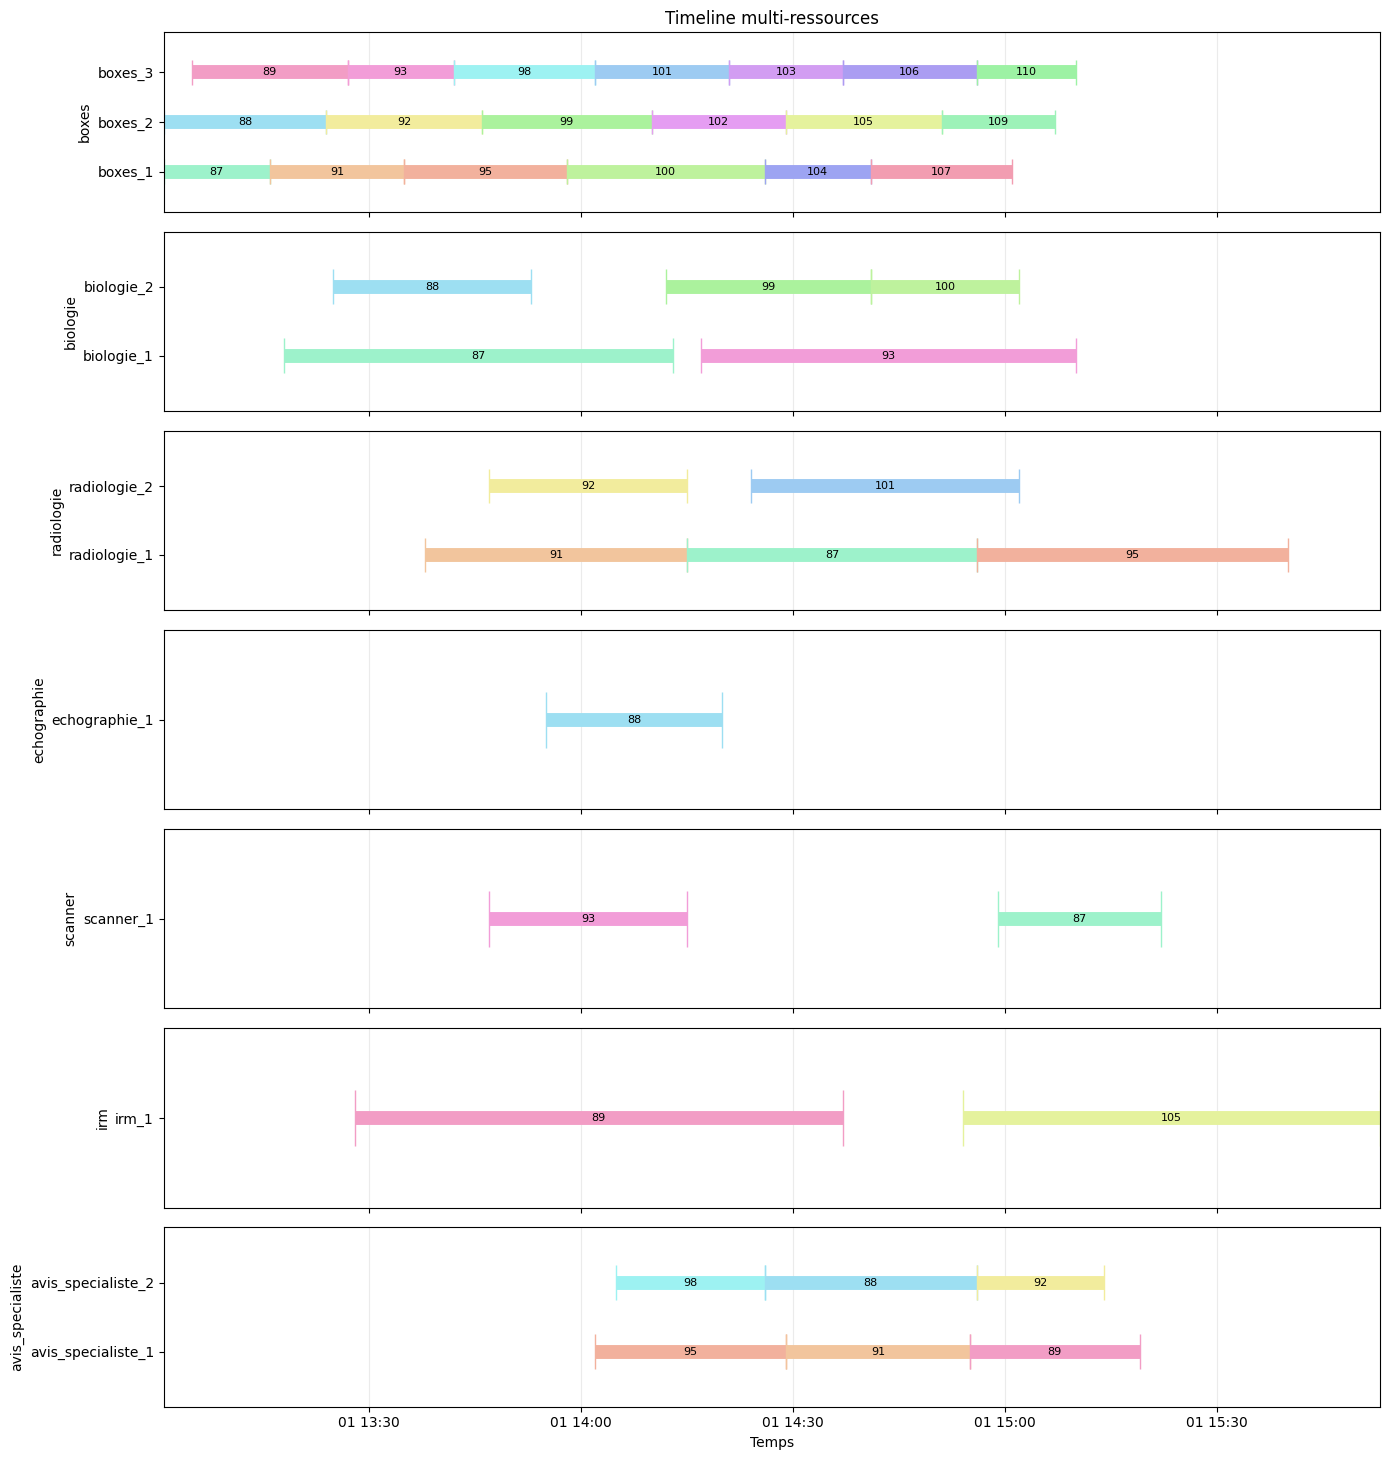

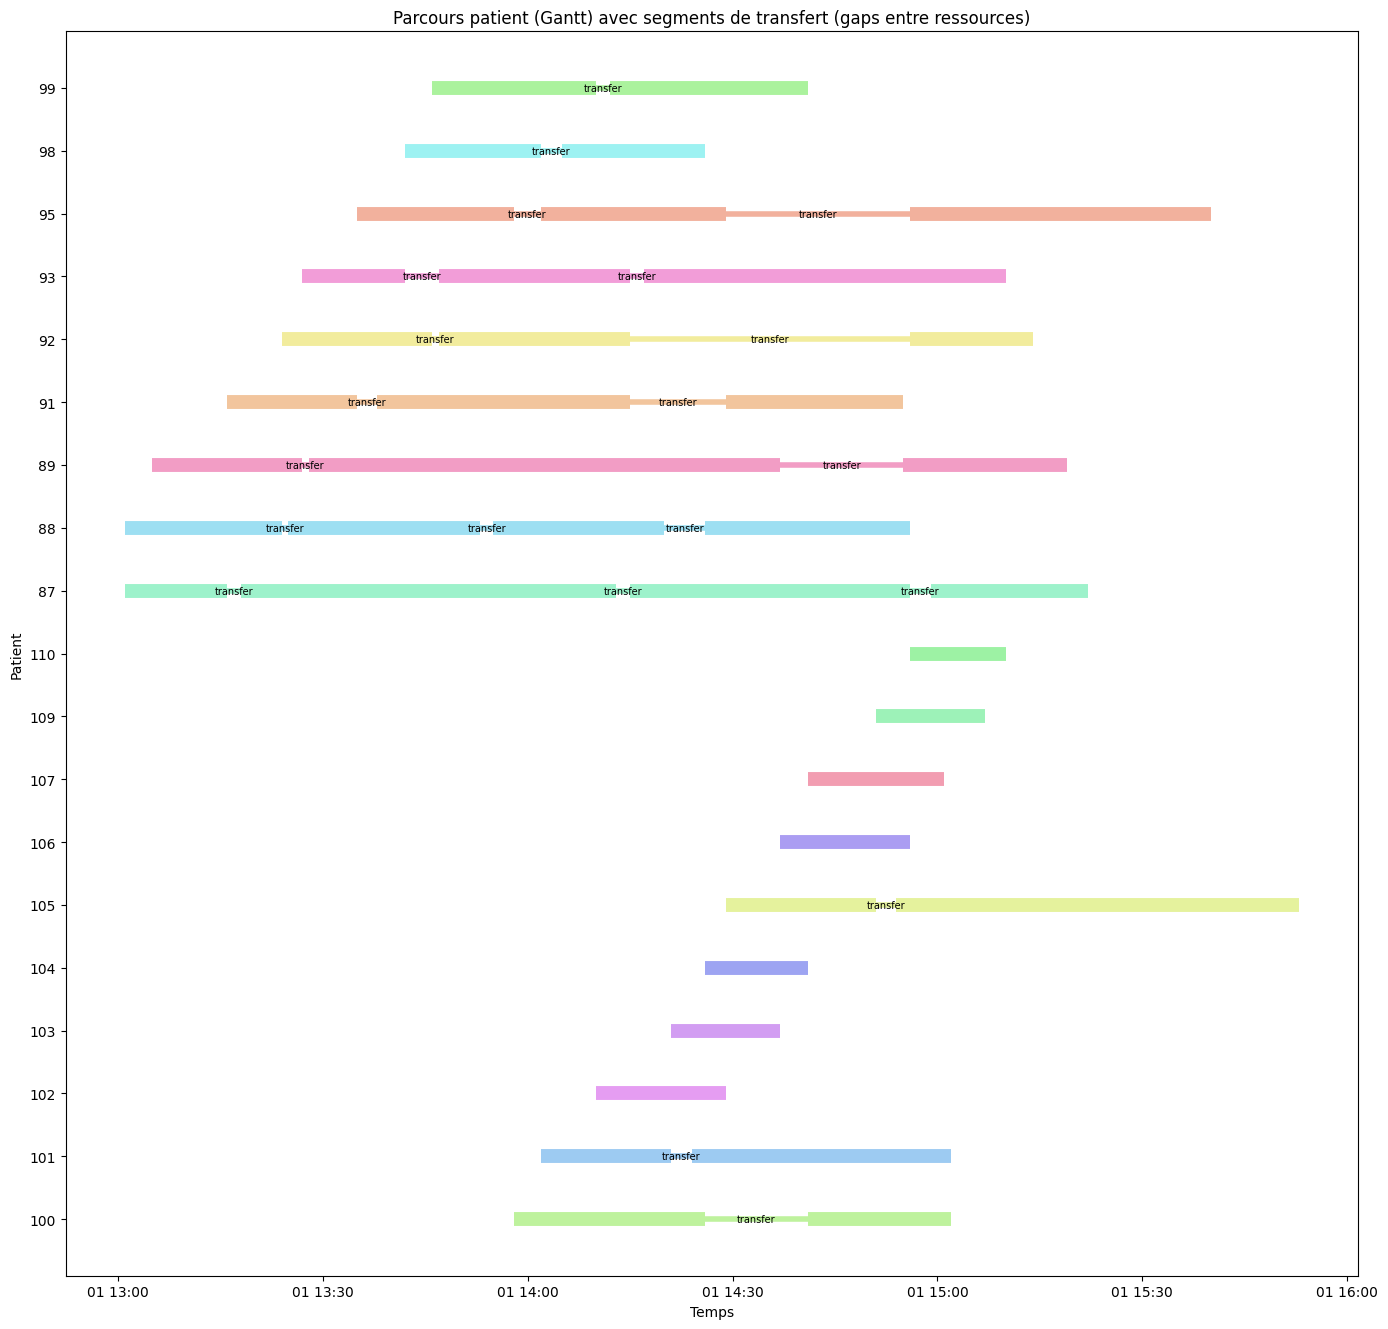

,patient_id,ccmu,t_arrivee,t_debut_box,attente_min
0,100,1,2016-06-01 13:41:00,2016-06-01 13:58:00,17.0
1,87,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
2,88,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
3,89,2,2016-06-01 13:05:00,2016-06-01 13:05:00,0.0
4,91,2,2016-06-01 13:13:00,2016-06-01 13:16:00,3.0
5,92,2,2016-06-01 13:16:00,2016-06-01 13:24:00,8.0
6,95,2,2016-06-01 13:25:00,2016-06-01 13:35:00,10.0
7,98,2,2016-06-01 13:34:00,2016-06-01 13:42:00,8.0
8,99,2,2016-06-01 13:36:00,2016-06-01 13:46:00,10.0
9,101,2,2016-06-01 13:42:00,2016-06-01 14:02:00,20.0


,ccmu,n,min,q1,median,q3,max,mean,std
0,1,1,17.0,17.00,17.0,17.00,17.0,17.00,0.000000
1,2,16,0.0,6.75,14.5,23.25,41.0,15.75,13.005127
2,3,2,9.0,11.50,14.0,16.50,19.0,14.00,7.071068


C:\Users\agus\AppData\Local\Temp\ipykernel_5256\1446228928.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


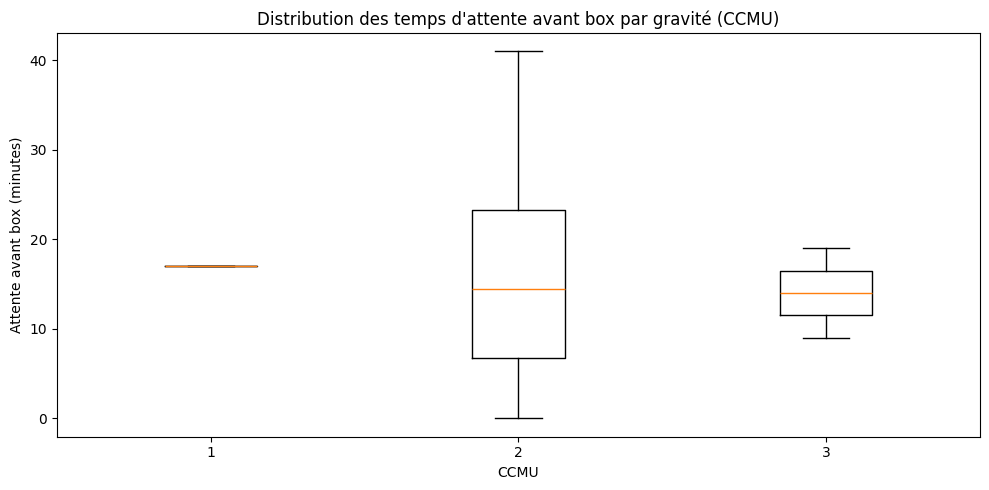

=== MODE: gravite ===


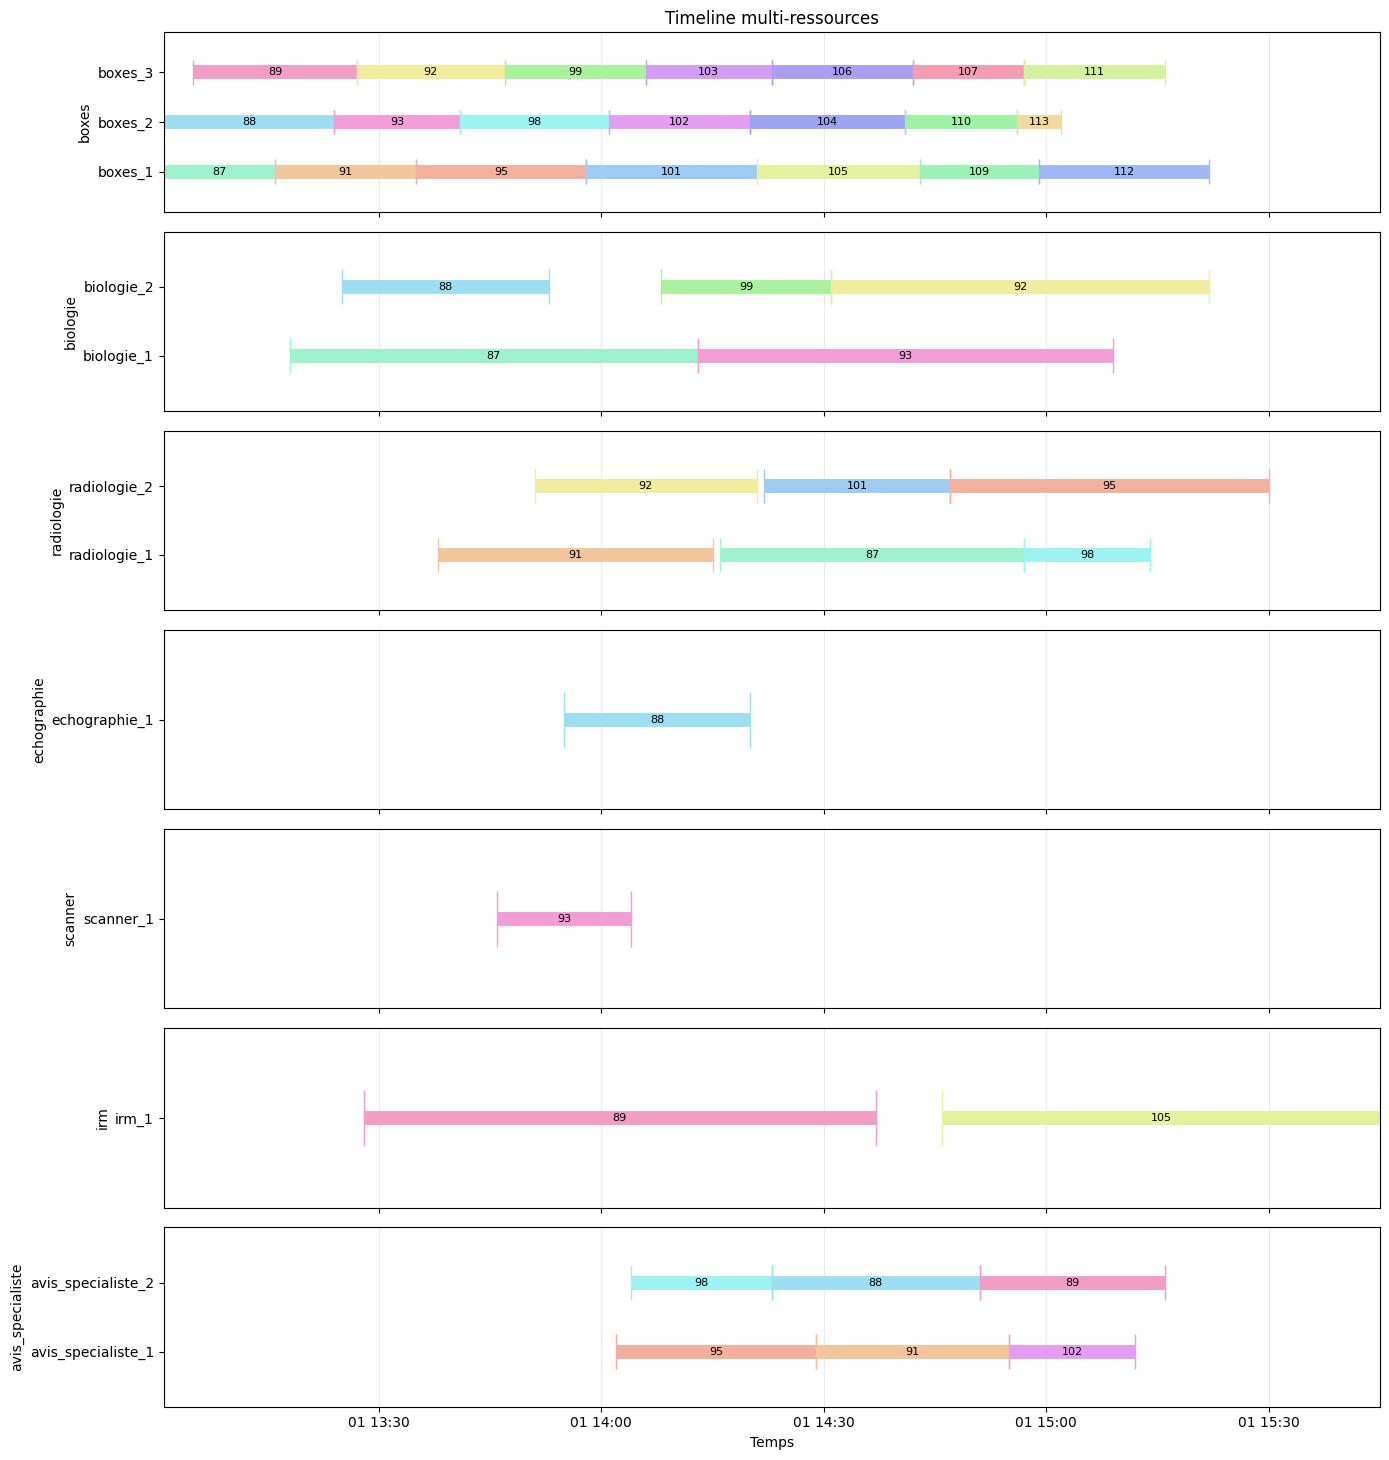

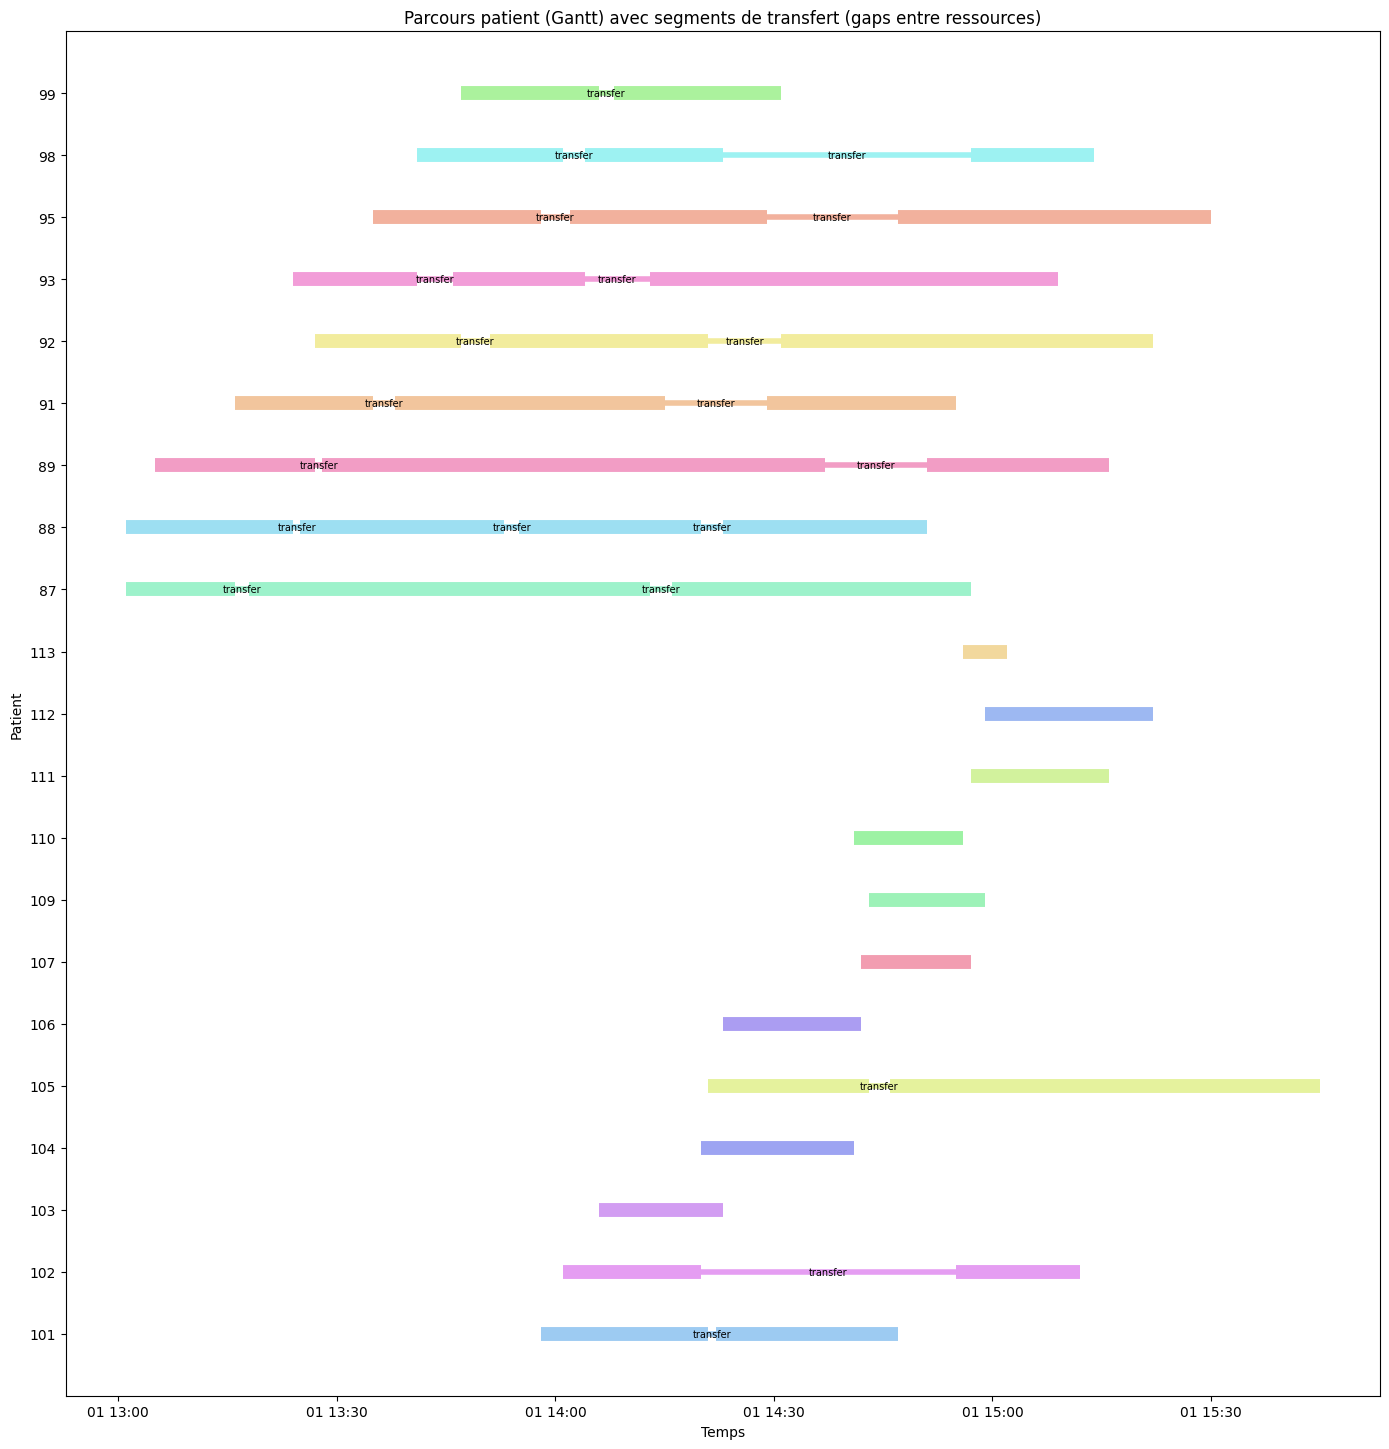

,patient_id,ccmu,t_arrivee,t_debut_box,attente_min
0,87,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
1,88,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
2,89,2,2016-06-01 13:05:00,2016-06-01 13:05:00,0.0
3,91,2,2016-06-01 13:13:00,2016-06-01 13:16:00,3.0
4,92,2,2016-06-01 13:16:00,2016-06-01 13:27:00,11.0
5,95,2,2016-06-01 13:25:00,2016-06-01 13:35:00,10.0
6,98,2,2016-06-01 13:34:00,2016-06-01 13:41:00,7.0
7,99,2,2016-06-01 13:36:00,2016-06-01 13:47:00,11.0
8,101,2,2016-06-01 13:42:00,2016-06-01 13:58:00,16.0
9,102,2,2016-06-01 13:42:00,2016-06-01 14:01:00,19.0


,ccmu,n,min,q1,median,q3,max,mean,std
0,2,18,0.0,7.75,11.0,17.0,35.0,12.555556,9.095715
1,3,2,4.0,4.50,5.0,5.5,6.0,5.000000,1.414214
2,5,1,7.0,7.00,7.0,7.0,7.0,7.000000,0.000000


C:\Users\agus\AppData\Local\Temp\ipykernel_5256\1446228928.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


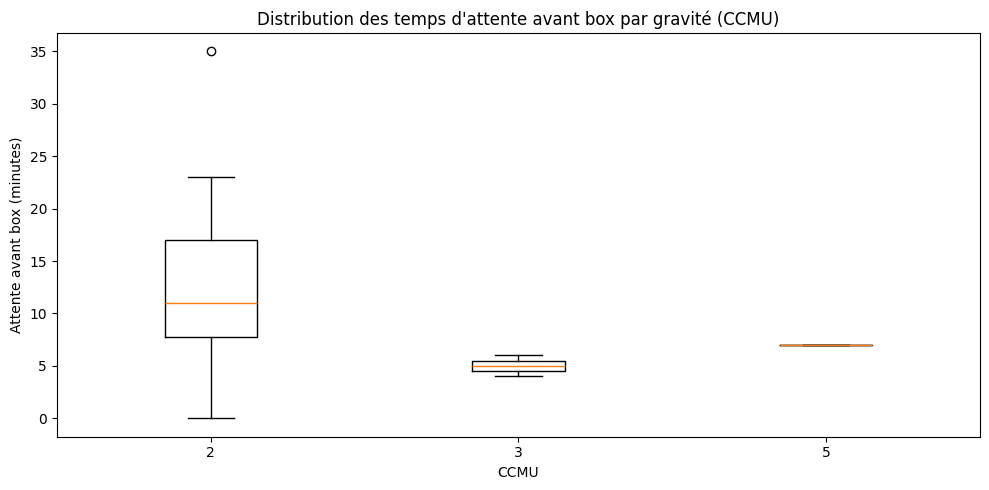

=== MODE: spt ===


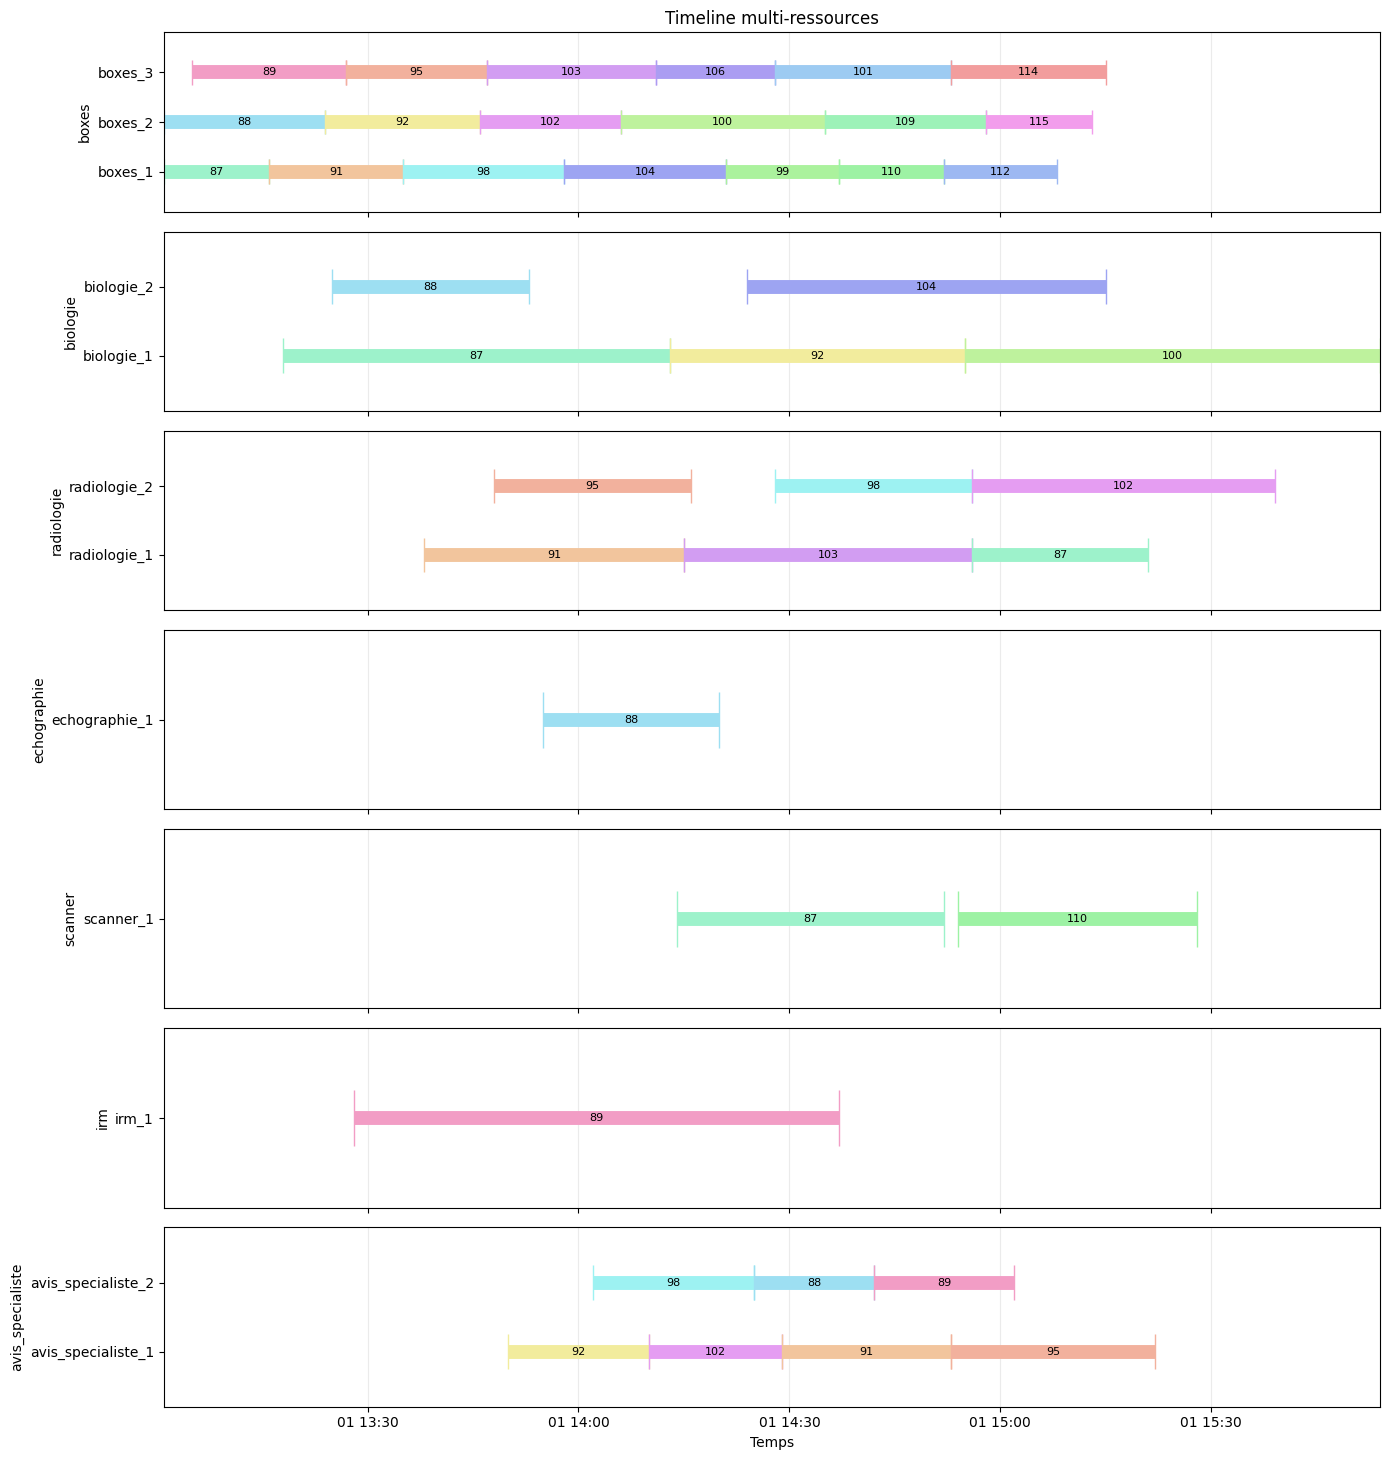

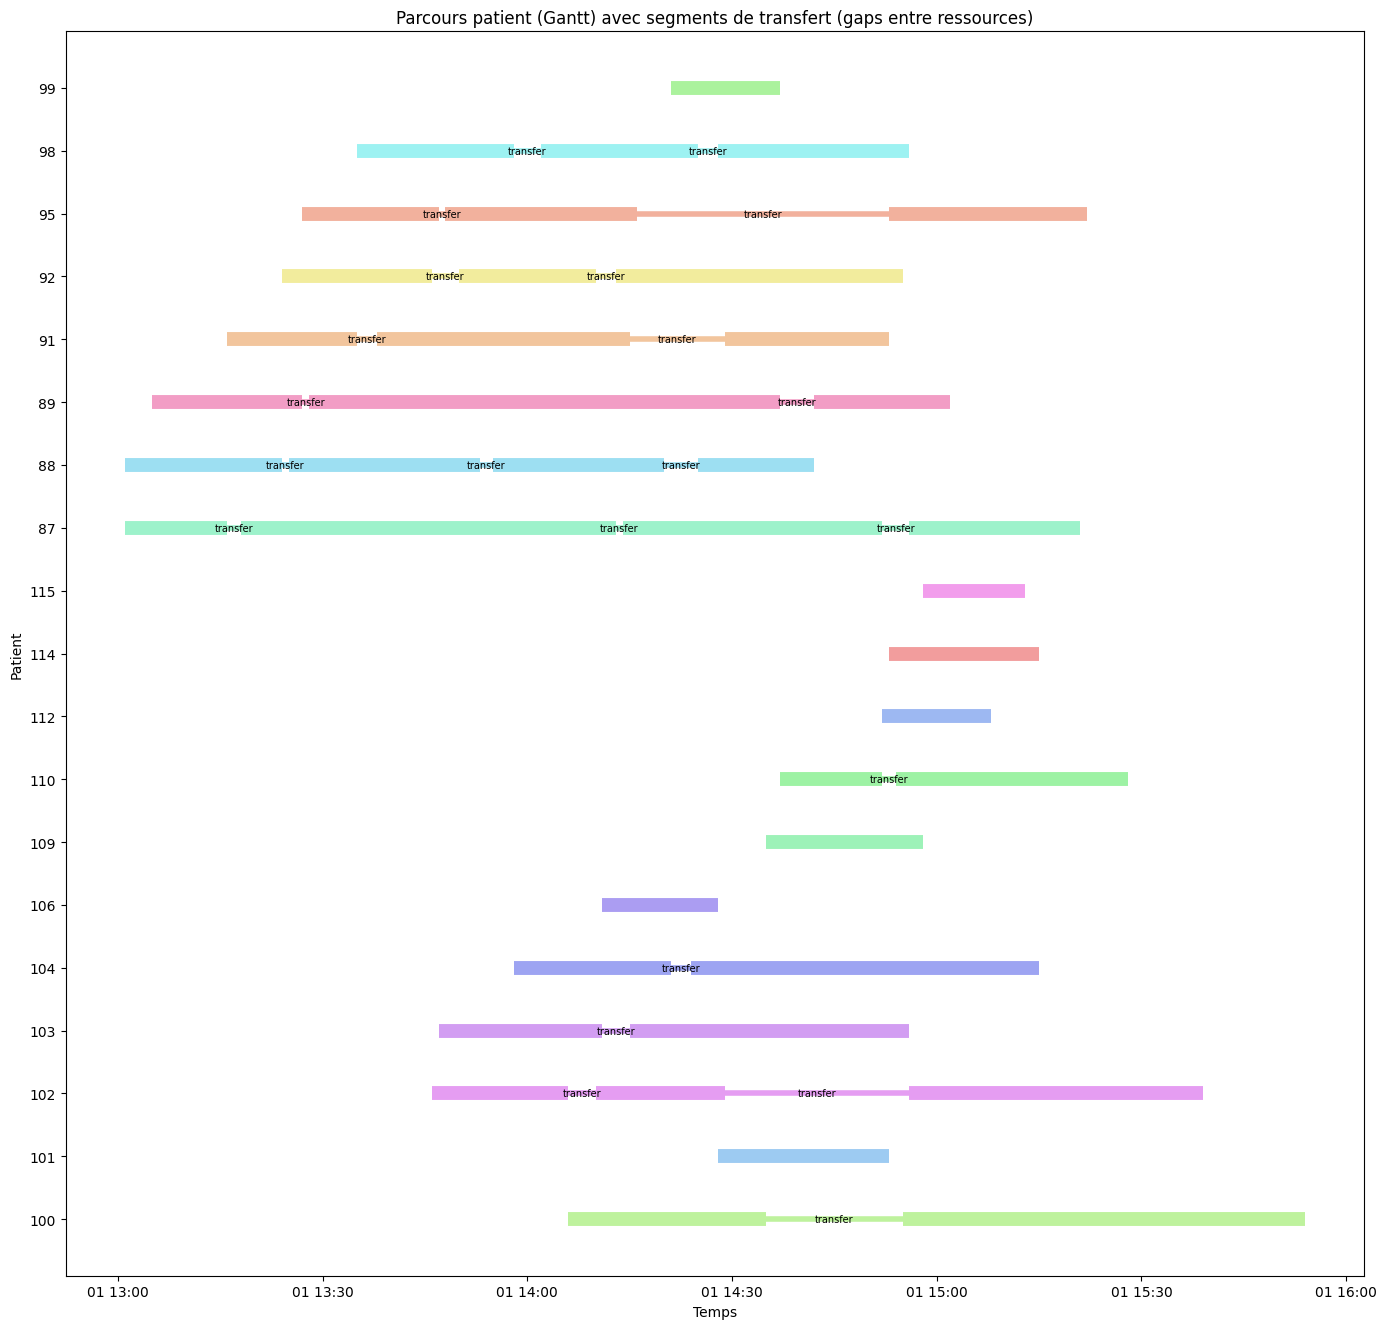

,patient_id,ccmu,t_arrivee,t_debut_box,attente_min
0,100,1,2016-06-01 13:41:00,2016-06-01 14:06:00,25.0
1,87,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
2,88,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
3,89,2,2016-06-01 13:05:00,2016-06-01 13:05:00,0.0
4,91,2,2016-06-01 13:13:00,2016-06-01 13:16:00,3.0
5,92,2,2016-06-01 13:16:00,2016-06-01 13:24:00,8.0
6,95,2,2016-06-01 13:25:00,2016-06-01 13:27:00,2.0
7,98,2,2016-06-01 13:34:00,2016-06-01 13:35:00,1.0
8,102,2,2016-06-01 13:42:00,2016-06-01 13:46:00,4.0
9,103,2,2016-06-01 13:44:00,2016-06-01 13:47:00,3.0


,ccmu,n,min,q1,median,q3,max,mean,std
0,1,1,25.0,25.0,25.0,25.0,25.0,25.000000,0.000000
1,2,17,0.0,1.0,3.0,8.0,46.0,8.294118,14.486048
2,3,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


C:\Users\agus\AppData\Local\Temp\ipykernel_5256\1446228928.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


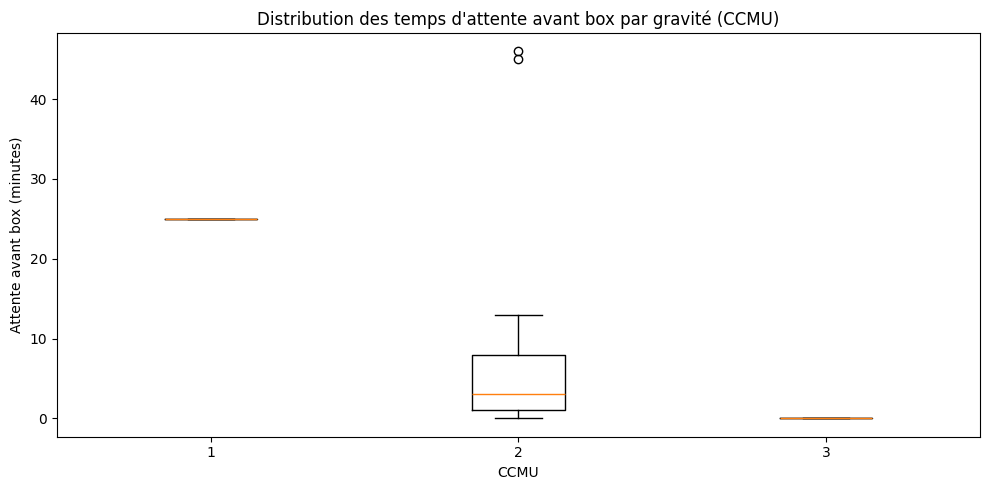

=== MODE: wspt ===


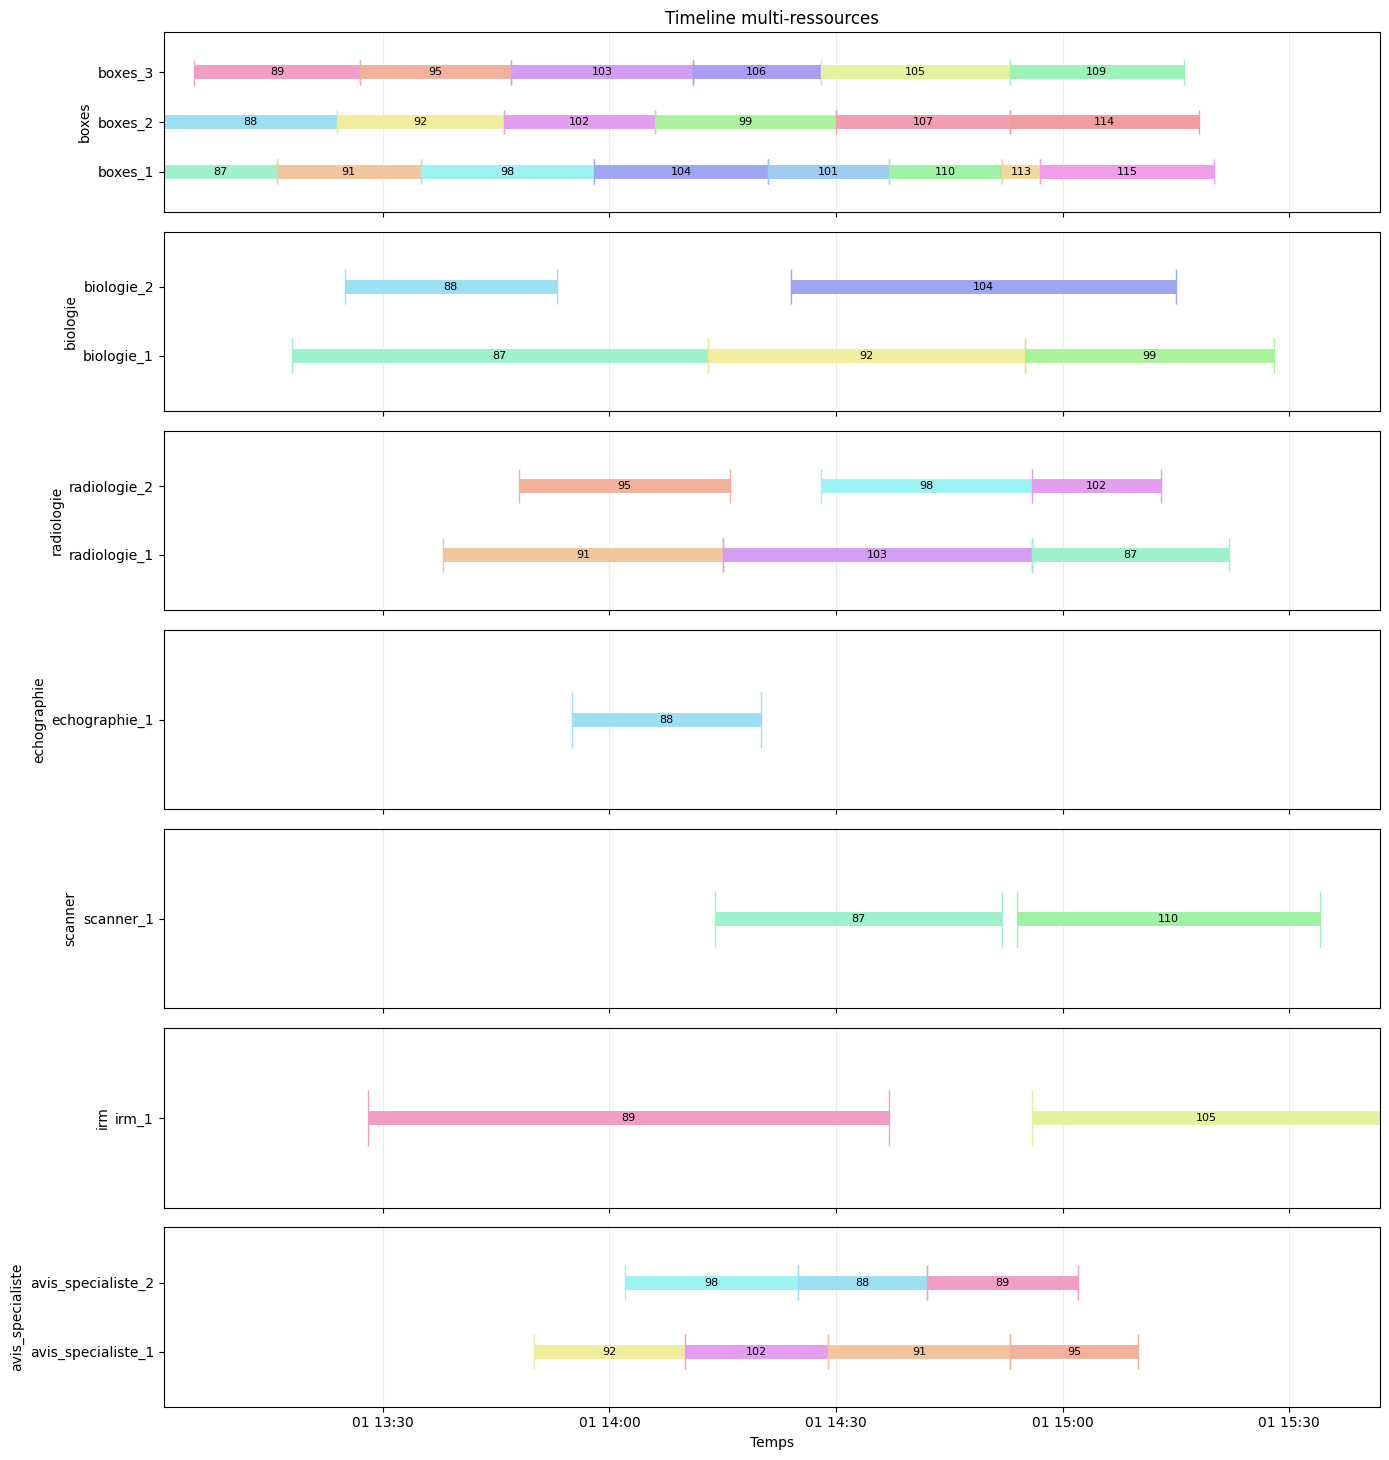

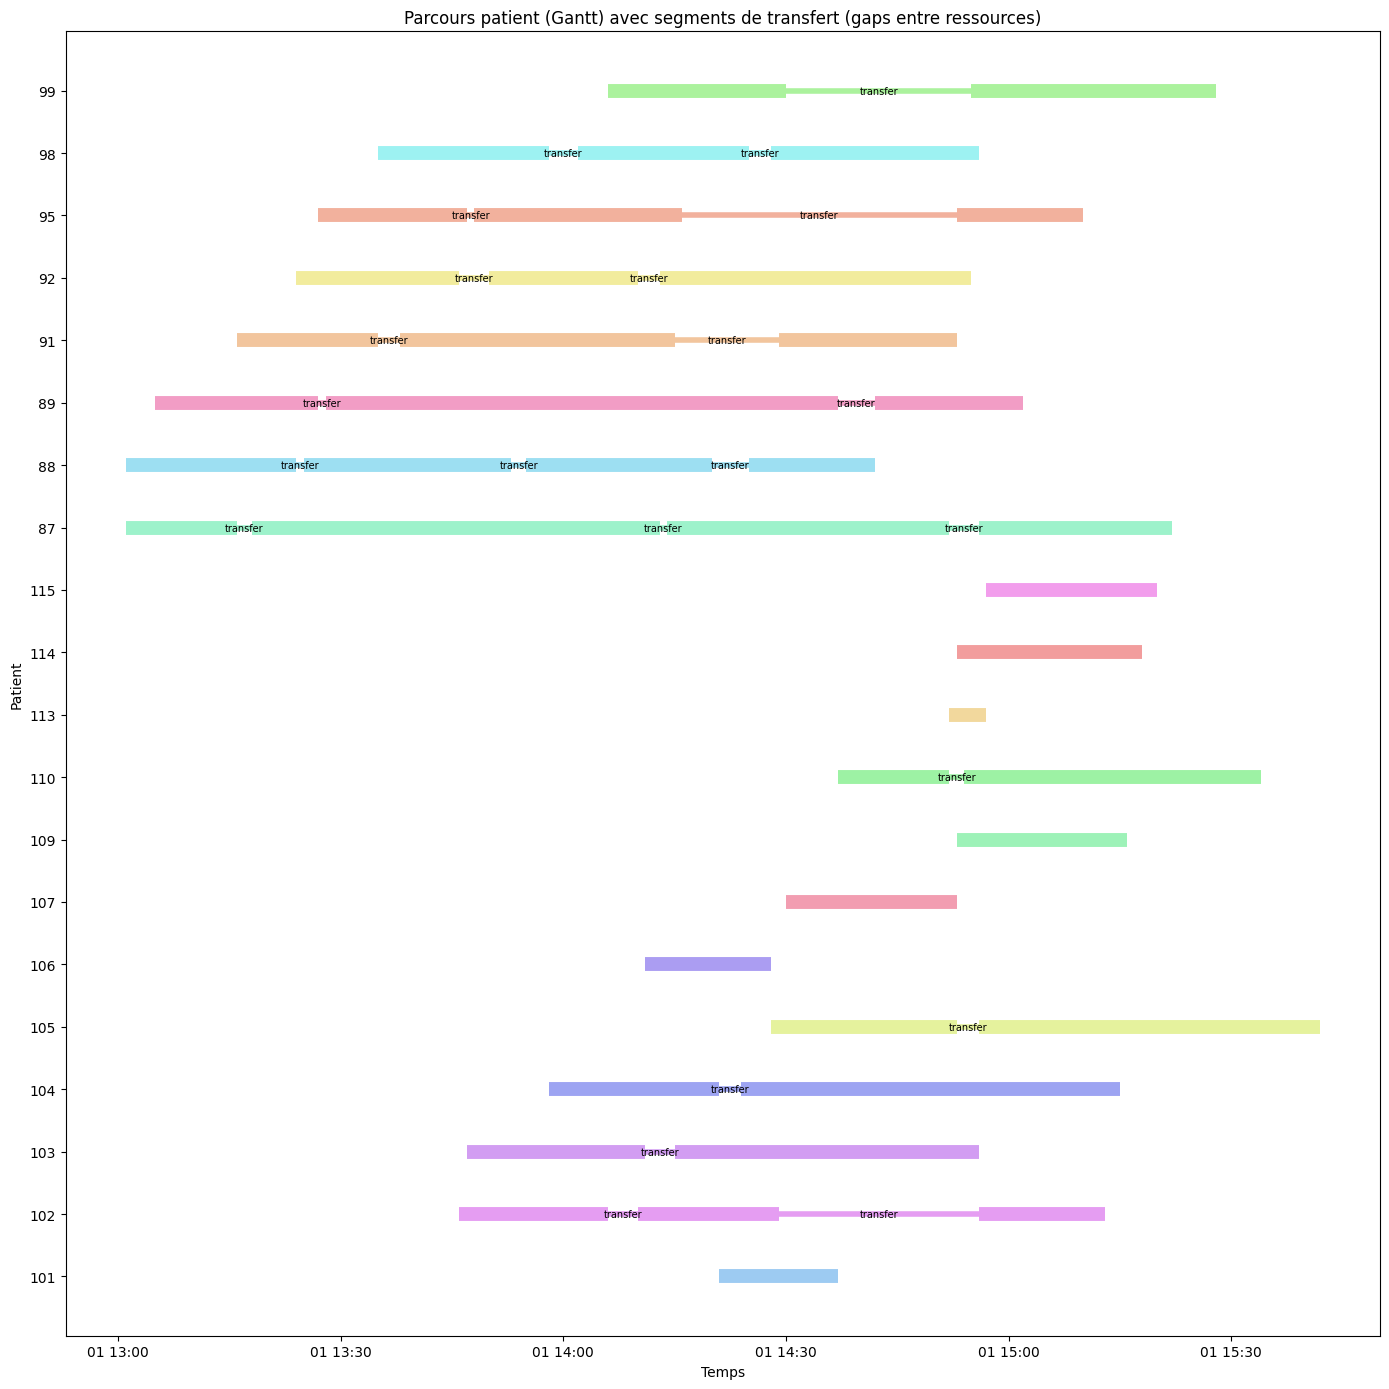

,patient_id,ccmu,t_arrivee,t_debut_box,attente_min
0,87,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
1,88,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
2,89,2,2016-06-01 13:05:00,2016-06-01 13:05:00,0.0
3,91,2,2016-06-01 13:13:00,2016-06-01 13:16:00,3.0
4,92,2,2016-06-01 13:16:00,2016-06-01 13:24:00,8.0
5,95,2,2016-06-01 13:25:00,2016-06-01 13:27:00,2.0
6,98,2,2016-06-01 13:34:00,2016-06-01 13:35:00,1.0
7,102,2,2016-06-01 13:42:00,2016-06-01 13:46:00,4.0
8,103,2,2016-06-01 13:44:00,2016-06-01 13:47:00,3.0
9,104,2,2016-06-01 13:45:00,2016-06-01 13:58:00,13.0


,ccmu,n,min,q1,median,q3,max,mean,std
0,2,18,0.0,1.0,3.0,12.5,39.0,8.611111,11.494955
1,3,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,5,1,3.0,3.0,3.0,3.0,3.0,3.000000,0.000000


C:\Users\agus\AppData\Local\Temp\ipykernel_5256\1446228928.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


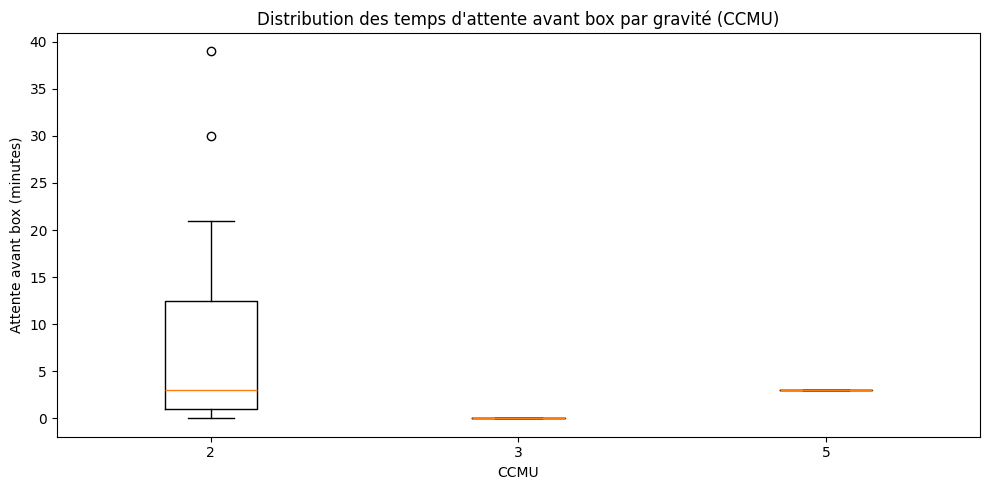

In [81]:
start = "2016-06-01 13:00:00"
end = "2016-06-01 15:00:00"

outputs = compare_modes_run(
    df_sma=df_sma,
    start=start,
    end=end,
    resources=resources,
    ccmu_to_priority=ccmu_to_priority,
    modes=("fifo", "gravite", "spt", "wspt"),
    step_minutes=1,
    seed=42,
    color_seed=42
)

compare_modes_show(outputs, show_slider=False)

Dans cette cellule, nous comparons les performances des différents modes d’ordonnancement à l’aide d’un graphique en barres.  
Le mode `fifo` est utilisé comme baseline afin d’estimer le gain moyen de temps d’attente avant l’entrée en box pour chaque stratégie.

Il est important de noter que ces résultats sont uniquement illustratifs. Pour obtenir des estimations réalistes, il serait nécessaire d’ajuster plusieurs paramètres du modèle, notamment :
- le nombre réel de ressources disponibles aux urgences du CHU de Lille,
- les durées de prise en charge dans le box selon la gravité des patients,
- les temps de transfert entre les différentes étapes du parcours de soin.

Cette analyse permet surtout de montrer que le modèle SMA construit est fonctionnel et capable de comparer différents modes d’ordonnancement.

,mode,patient_id,ccmu,t_arrivee,sim_wait_min,sim_total_min,real_total_min,done
0,fifo,87,2,2016-06-01 13:01:00,0.0,NaN,391.0,0
1,fifo,88,2,2016-06-01 13:01:00,0.0,115.0,425.0,1
2,fifo,89,2,2016-06-01 13:05:00,0.0,NaN,562.0,0
3,fifo,91,2,2016-06-01 13:13:00,3.0,102.0,191.0,1
4,fifo,92,2,2016-06-01 13:16:00,8.0,NaN,269.0,0
...,...,...,...,...,...,...,...,...
99,wspt,113,5,2016-06-01 14:49:00,3.0,8.0,418.0,1
100,wspt,114,2,2016-06-01 14:53:00,0.0,NaN,111.0,0
101,wspt,115,2,2016-06-01 14:56:00,1.0,NaN,277.0,0
102,wspt,116,3,2016-06-01 15:00:00,NaN,NaN,334.0,0


,mode,n_patients_with_wait,mean_wait_min,median_wait_min,reduction_mean_wait_vs_fifo_min,reduction_median_wait_vs_fifo_min
0,fifo,19,15.631579,17.0,0.000000,0.0
1,gravite,21,11.571429,11.0,4.060150,6.0
2,spt,19,8.736842,3.0,6.894737,14.0
3,wspt,20,7.900000,3.0,7.731579,14.0


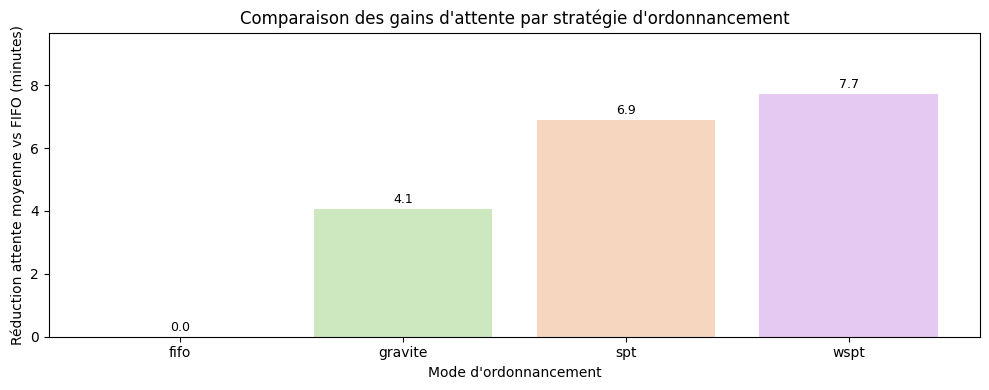

In [74]:
df_perf_all = build_mode_performance(outputs)
display(df_perf_all)

df_wait_gain = waiting_reduction_summary(df_perf_all, baseline_mode="fifo")
display(df_wait_gain)
plot_wait_reduction_bar(df_wait_gain)

### Simulation avec slider

Nous relançons ici la simulation en ajoutant un slider qui permet de se déplacer dans le temps de la simulation.  
Cet outil permet d’observer, à chaque instant, combien de patients se trouvent dans les différentes étapes du parcours aux urgences :

- en attente d’un box,
- en box,
- en attente d’un examen,
- en cours d’examen,
- déjà sortis des urgences.

Cette visualisation permet de mieux suivre la dynamique du système au cours du temps.

In [77]:
start = "2016-06-01 13:00:00"
end = "2016-06-01 15:00:00"

model, df_evolution = run_urgences(
    df_sma=df_sma,
    start=start,
    end=end,
    resources=resources,
    ccmu_to_priority=ccmu_to_priority,
    mode_ordonnancement="fifo",
    step_minutes=1,
    seed=42
)

patient_color_map = build_patient_color_map(model, seed=42, saturation=0.35, value=0.95)

C:\Users\agus\AppData\Local\Temp\ipykernel_5256\2322473135.py:30: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in Mesa 3.1. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = BaseScheduler(self)


In [ ]:
slider_states_bar(df_evolution)

IntSlider(value=0, continuous_update=False, description='Minute', max=120)

Output()

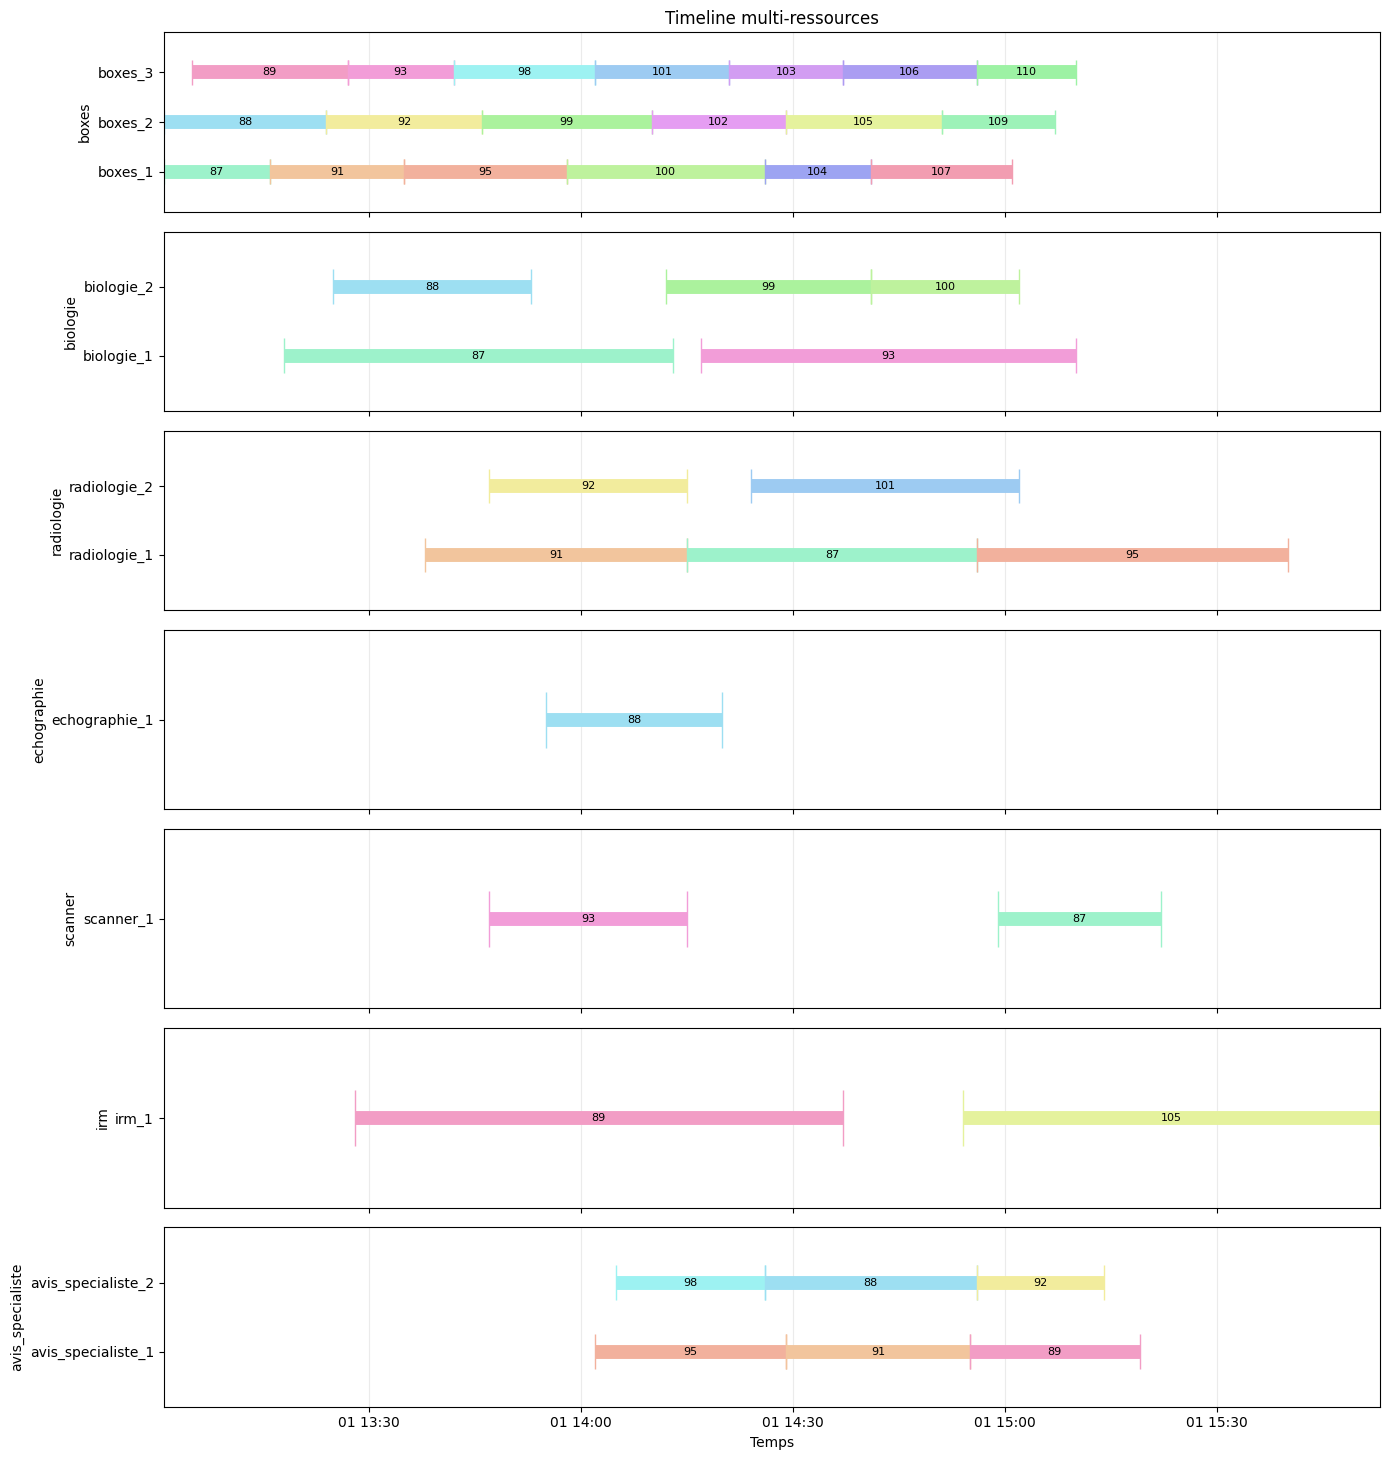

In [ ]:
plot_resources_binary_timeline(model, patient_color_map, max_labels_per_axis=300)

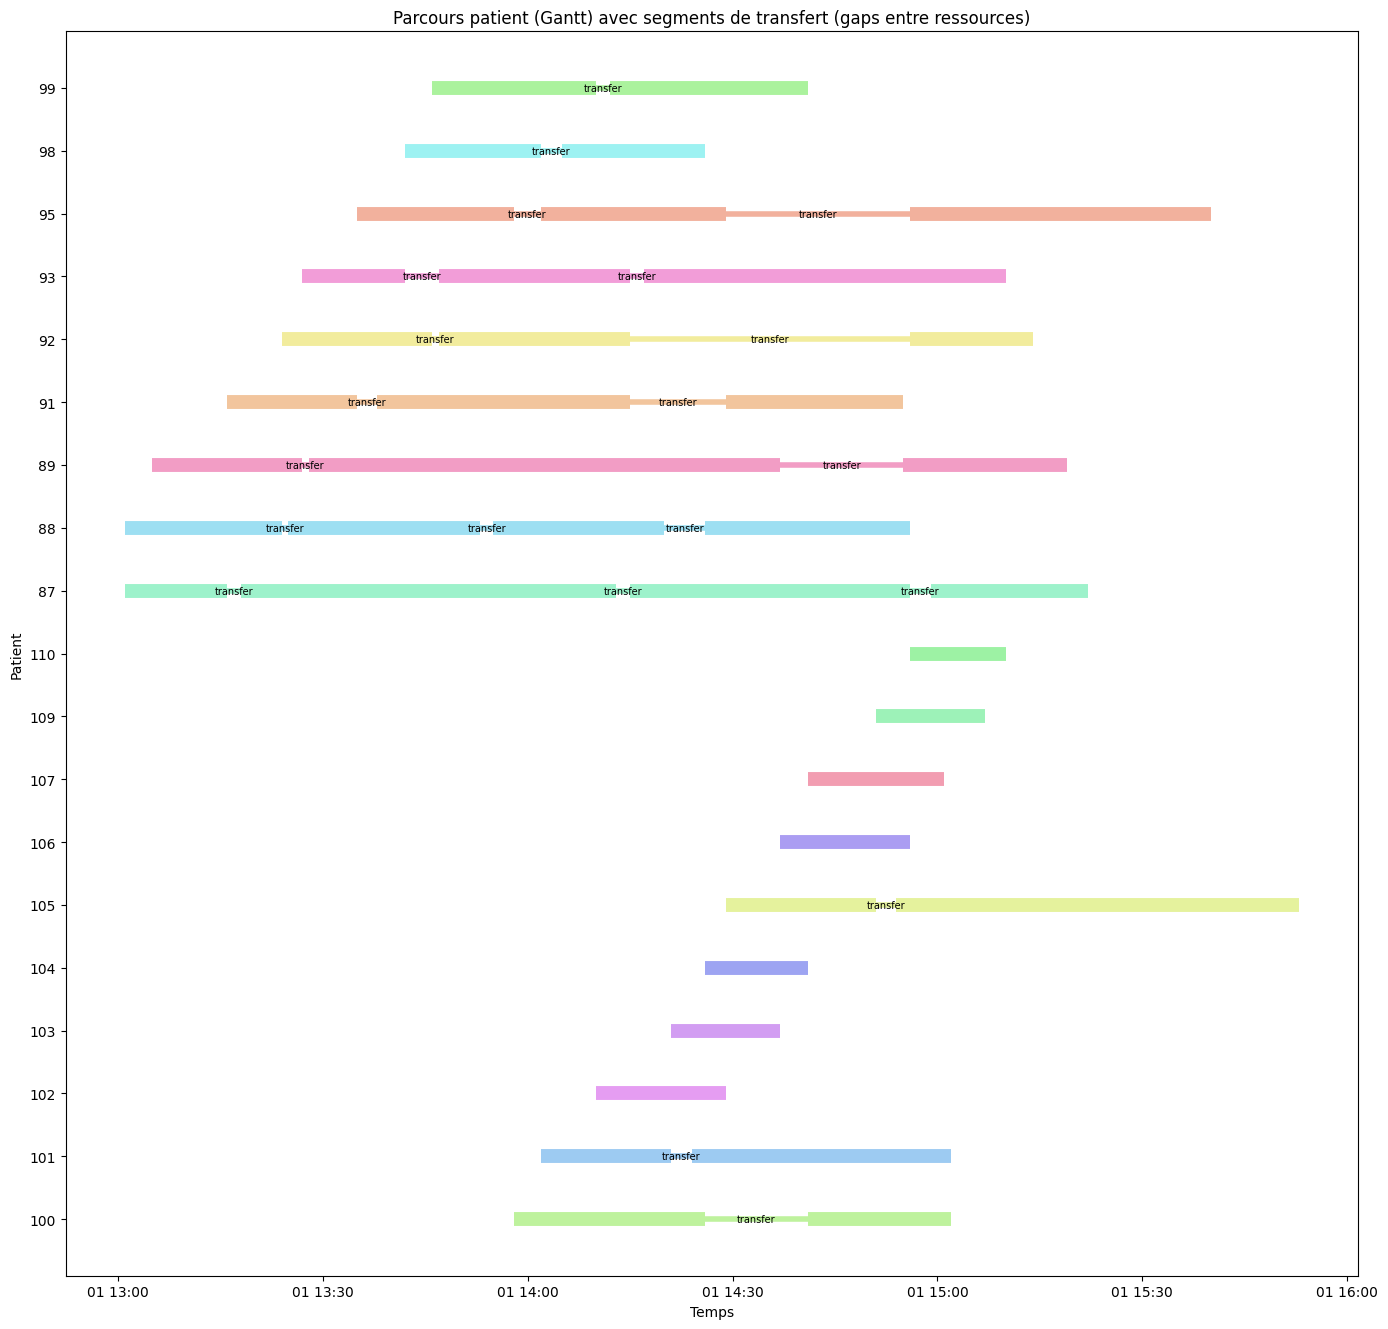

In [ ]:
patient_color_map = build_patient_color_map(model, seed=42, saturation=0.35, value=0.95)
plot_patient_journey_gantt(model, patient_color_map, max_patients=40)

,patient_id,ccmu,t_arrivee,t_debut_box,attente_min
0,100,1,2016-06-01 13:41:00,2016-06-01 13:58:00,17.0
1,87,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
2,88,2,2016-06-01 13:01:00,2016-06-01 13:01:00,0.0
3,89,2,2016-06-01 13:05:00,2016-06-01 13:05:00,0.0
4,91,2,2016-06-01 13:13:00,2016-06-01 13:16:00,3.0
5,92,2,2016-06-01 13:16:00,2016-06-01 13:24:00,8.0
6,95,2,2016-06-01 13:25:00,2016-06-01 13:35:00,10.0
7,98,2,2016-06-01 13:34:00,2016-06-01 13:42:00,8.0
8,99,2,2016-06-01 13:36:00,2016-06-01 13:46:00,10.0
9,101,2,2016-06-01 13:42:00,2016-06-01 14:02:00,20.0


,ccmu,n,min,q1,median,q3,max,mean,std
0,1,1,17.0,17.00,17.0,17.00,17.0,17.00,0.000000
1,2,16,0.0,6.75,14.5,23.25,41.0,15.75,13.005127
2,3,2,9.0,11.50,14.0,16.50,19.0,14.00,7.071068


C:\Users\agus\AppData\Local\Temp\ipykernel_26580\1446228928.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


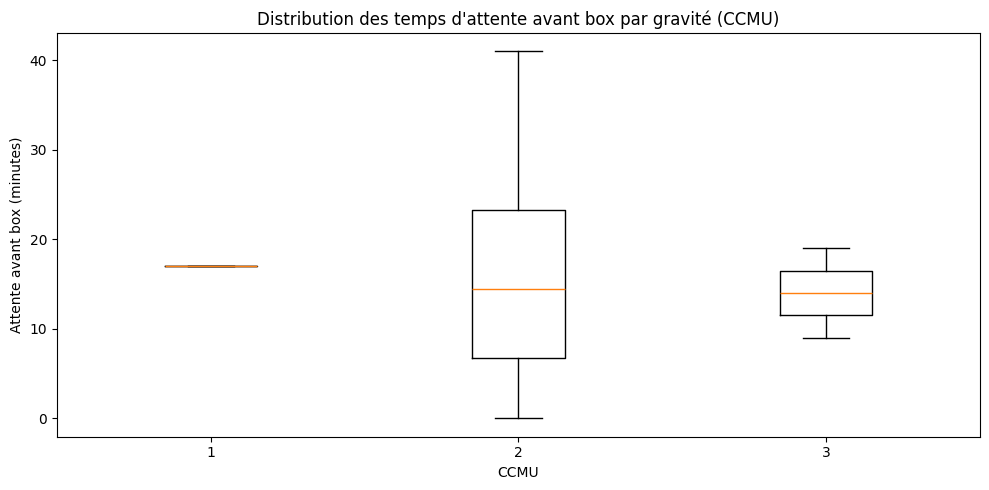

In [ ]:
df_wait = build_waiting_times_df(model)
display(df_wait)

df_wait_summary = waiting_summary_by_ccmu(df_wait)
display(df_wait_summary)

plot_waiting_boxplot_by_ccmu(df_wait)